### DSC 640 - Milestone 3
#### Nana Noda-Morgan

In [103]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import re

pd.set_option("display.max_columns", 200)
plt.rcParams["figure.figsize"] = (8,4)
plt.rcParams["axes.grid"] = True
data = pd.read_excel("nationaldatabaseofchildcareprices.xlsx", sheet_name="nationaldatabaseofchildcare")
AFFORD     = 0.07   # 7% affordability benchmark

In [105]:
cols_all = data.columns.tolist()

id_cols = [c for c in ["County_FIPS_Code","County_Name","State_Abbreviation","StudyYear"] if c in cols_all]
price_candidates  = [c for c in ["MFCCInfant","MCCCInfant","MFCCToddler","MCCCToddler","MFCCPreschool","MCCCPreschool"] if c in cols_all]
income_candidates = [c for c in ["MHI","iMHI","MHI_2018","iMHI_2018"] if c in cols_all]
unemp_candidates = [c for c in ["FUNR_20to64","UNR_20to64"] if c in cols_all]

print("ID cols:", id_cols)
print("Price candidates:", price_candidates)
print("Income candidates:", income_candidates)
print("Unemployment candidates:", unemp_candidates)
assert id_cols and price_candidates and income_candidates and unemp_candidates, "Missing expected columns; check file/sheet."


ID cols: ['County_FIPS_Code', 'County_Name', 'State_Abbreviation', 'StudyYear']
Price candidates: ['MFCCInfant', 'MFCCToddler', 'MFCCPreschool']
Income candidates: ['MHI', 'iMHI', 'MHI_2018', 'iMHI_2018']
Unemployment candidates: ['FUNR_20to64', 'UNR_20to64']


In [107]:
#Load only the needed columns for less cleaning
use_cols = list(dict.fromkeys(id_cols + price_candidates + income_candidates + unemp_candidates))  # dedupe, keep order
df_raw = pd.read_excel("nationaldatabaseofchildcareprices.xlsx", sheet_name="nationaldatabaseofchildcare", usecols=use_cols)

# FIPS as zero-padded string, StudyYear as int
if "County_FIPS_Code" in df_raw.columns:
    df_raw["County_FIPS_Code"] = (df_raw["County_FIPS_Code"]
                                  .astype(str)
                                  .str.replace(r"\.0$", "", regex=True)
                                  .str.zfill(5))

if "StudyYear" in df_raw.columns:
    df_raw["StudyYear"] = pd.to_numeric(df_raw["StudyYear"], errors="coerce").astype("Int64")

#drop duplicate county-year rows
if set(["County_FIPS_Code","StudyYear"]).issubset(df_raw.columns):
    before = len(df_raw)
    df_raw = df_raw.drop_duplicates(subset=["County_FIPS_Code","StudyYear"])
    print("Dropped duplicate county-year rows:", before - len(df_raw))

df_raw.head(3)

Dropped duplicate county-year rows: 0


,State_Abbreviation,County_Name,County_FIPS_Code,StudyYear,UNR_20to64,FUNR_20to64,MHI,MHI_2018,iMHI,iMHI_2018,MFCCInfant,MFCCToddler,MFCCPreschool
0,AL,Autauga County,01001,2008,4.6,3.5,50837.0,58462.55,0,1,83.45,83.45,81.40
1,AL,Autauga County,01001,2009,4.8,4.6,51463.0,60211.71,0,1,87.39,87.39,85.68
2,AL,Autauga County,01001,2010,5.1,4.6,53255.0,61775.80,0,1,91.33,91.33,89.96


In [109]:
#Pick a primary price column and a clean snapshot year

cov_by_col = {}
for c in price_candidates:
    cov_by_col[c] = df_raw.groupby("StudyYear")[c].apply(lambda s: s.notna().mean()).mean()


primary_price_col = max(cov_by_col, key=cov_by_col.get)
print("Primary price:", primary_price_col, "| mean coverage:", round(cov_by_col[primary_price_col], 3))

#Choose the latest year with reasonable coverage (≥60%) for that column
per_year_cov = df_raw.groupby("StudyYear")[primary_price_col].apply(lambda s: s.notna().mean()).sort_index()
candidate_years = per_year_cov[per_year_cov >= 0.60].index.tolist()
snapshot_year = int(candidate_years[-1]) if candidate_years else int(per_year_cov.dropna().index[-1])
print("Chosen snapshot YEAR:", snapshot_year)

Primary price: MFCCInfant | mean coverage: 0.676
Chosen snapshot YEAR: 2018


In [111]:
#Attach a single income column as 'income' and build a snapshot frame
#prefer year-specific income (MHI or iMHI), otherwise use _2018
if "MHI" in income_candidates:
    income_col = "MHI"
elif "iMHI" in income_candidates:
    income_col = "iMHI"
elif "MHI_2018" in income_candidates:
    income_col = "MHI_2018"
else:
    income_col = "iMHI_2018"

#Start with id + flagship price
df = df_raw[id_cols + [primary_price_col]].copy()

# Merge income -> 'income'
df = df.drop(columns=[c for c in df.columns if c.lower()=="income"], errors="ignore")
if income_col.endswith("_2018"):
    attach = (df_raw[["County_FIPS_Code", income_col]]
              .drop_duplicates()
              .rename(columns={income_col: "income"}))
    df = df.merge(attach, on="County_FIPS_Code", how="left")
else:
    attach = (df_raw[["County_FIPS_Code","StudyYear", income_col]]
              .drop_duplicates()
              .rename(columns={income_col: "income"}))
    df = df.merge(attach, on=["County_FIPS_Code","StudyYear"], how="left")

#Merge female unemployment
attach = (df_raw[["County_FIPS_Code","StudyYear", "FUNR_20to64"]]
          .drop_duplicates()
         )
df = df.merge(attach, on=["County_FIPS_Code","StudyYear"], how="left")

#Keep 2018
base = (df[df["StudyYear"] == snapshot_year]
        .dropna(subset=[primary_price_col, "income"])
        .copy())

#Since prices are weekly, annualize
base["annual_price"] = base[primary_price_col] * 52
base["burden"] = base["annual_price"] / base["income"]

#Just in case drop nonpositive or clearly invalid
base = base[(base["annual_price"] > 0) & (base["income"] > 0)]

print(f"Snapshot {snapshot_year}: rows (counties) = {len(base):,}")
print("Columns available:", list(base.columns))

Snapshot 2018: rows (counties) = 2,348
Columns available: ['County_FIPS_Code', 'County_Name', 'State_Abbreviation', 'StudyYear', 'MFCCInfant', 'income', 'FUNR_20to64', 'annual_price', 'burden']


In [10]:
import matplotlib as mpl
##Define colors
ACCENT_BLUE  = "#2F6FED"   # benchmark accent
NEUTRAL_BAR  = "#C7CBD1"   # bars
NEUTRAL_EDGE = "#8A9099"   # median/axes
GRID_COLOR   = "#E6E8EB"
TITLE_COLOR  = "#111111"
AXIS_GRAY    = "#6B7280"

mpl.rcParams.update({
    "figure.dpi": 150,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": NEUTRAL_EDGE,
    "axes.titlesize": 14, "axes.titlelocation": "left",
    "axes.labelsize": 10,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "text.color": TITLE_COLOR,
    "grid.color": GRID_COLOR, "grid.linestyle": "-", "grid.linewidth": 0.8,
})

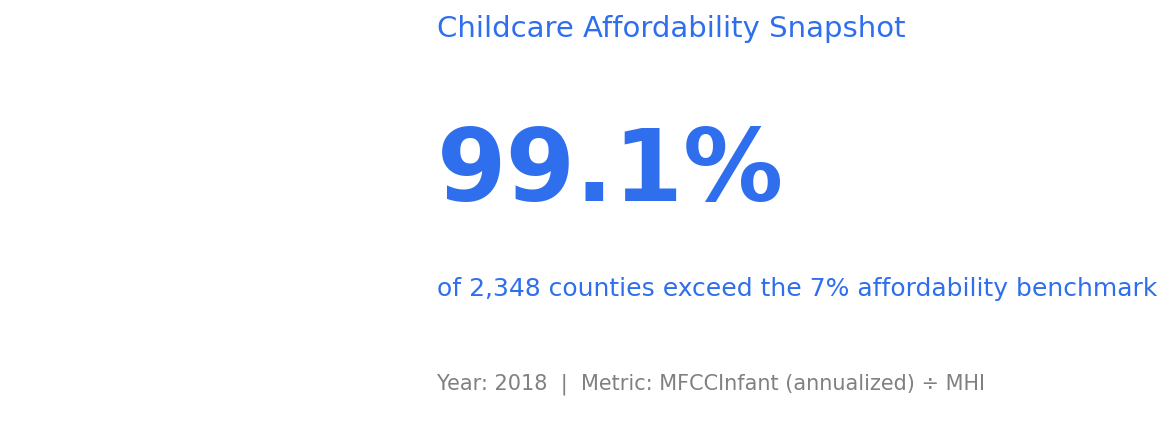

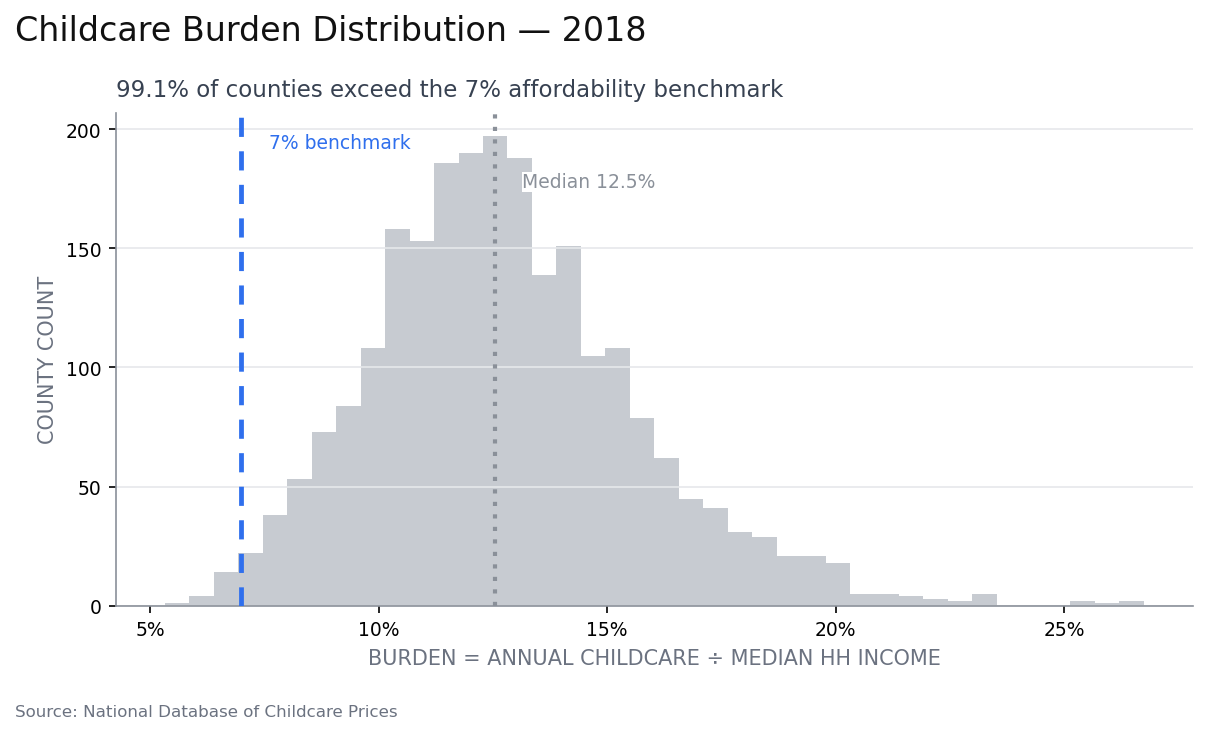

In [31]:
## First visualization -> histogram with 7% benchmark and median line
import matplotlib.ticker as mtick

share_above = (base["burden"] > AFFORD).mean()
median_burden = base["burden"].median()
n_counties = len(base)

#centered big-number tile/card
fig = plt.figure(figsize=(7.5,3.2))
fig.suptitle("Childcare Affordability Snapshot", y=0.95, fontsize=14, ha="left", color=ACCENT_BLUE)
fig.text(0.5, 0.62, f"{share_above*100:.1f}%", ha="left", va="center",
         fontsize=48, fontweight="bold", color=ACCENT_BLUE)
fig.text(0.5, 0.38, f"of {n_counties:,} counties exceed the 7% affordability benchmark",
         ha="left", va="center", fontsize=12, color=ACCENT_BLUE)
fig.text(0.5, 0.18, f"Year: {snapshot_year}  |  Metric: {primary_price_col} (annualized) ÷ {income_col}",
         ha="left", va="center", fontsize=10, color="gray")
plt.axis("off")
plt.show()

#Histogram with benchmark + median, percent axis
s = base["burden"].dropna()
share_above   = (s > AFFORD).mean()
median_burden = s.median()

fig, ax = plt.subplots(figsize=(8, 4.6))
plt.subplots_adjust(top=0.82)
ax.hist(s, bins=40, color=NEUTRAL_BAR, edgecolor="none")

# Lines
ax.axvline(AFFORD,color=ACCENT_BLUE,  linestyle=(0,(4,3)), linewidth=2.3, zorder=3)
ax.axvline(median_burden, color=NEUTRAL_EDGE, linestyle=(0,(1,2)), linewidth=2.0, zorder=3)

#title + subtitle both left-aligned
fig.suptitle(f"Childcare Burden Distribution — {snapshot_year}",
             x=0.0, ha="left", fontsize=16, color=TITLE_COLOR)
ax.set_title(f"{share_above*100:.1f}% of counties exceed the 7% affordability benchmark",
             loc="left", fontsize=11, color="#374151", pad=8)

# Labels in all caps and gray; percent x-axis with 0 decimals and lighter gridlines
ax.set_xlabel("BURDEN = ANNUAL CHILDCARE ÷ MEDIAN HH INCOME", color=AXIS_GRAY)
ax.set_ylabel("COUNTY COUNT", color=AXIS_GRAY)
ax.xaxis.set_major_locator(mtick.MultipleLocator(0.05))
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))
ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(nbins=5, integer=True))
ax.yaxis.grid(True); ax.xaxis.grid(False)


ymax = ax.get_ylim()[1]
dx = 0.006 
ax.annotate("7% benchmark",
            xy=(AFFORD, ymax*0.94), xytext=(AFFORD+dx, ymax*0.94),
            ha="left", va="center", color=ACCENT_BLUE, fontsize=9,
            bbox=dict(facecolor="white", edgecolor="none", pad=0.2))

ax.annotate(f"Median {median_burden*100:.1f}%",
            xy=(median_burden, ymax*0.86), xytext=(median_burden+dx, ymax*0.86),
            ha="left", va="center", color=NEUTRAL_EDGE, fontsize=9,
            bbox=dict(facecolor="white", edgecolor="none", pad=0.2))

# Source note (small, left)
fig.text(0.0, -0.02,
         "Source: National Database of Childcare Prices",
         ha="left", va="top", fontsize=8, color=AXIS_GRAY)

plt.tight_layout()
plt.show()

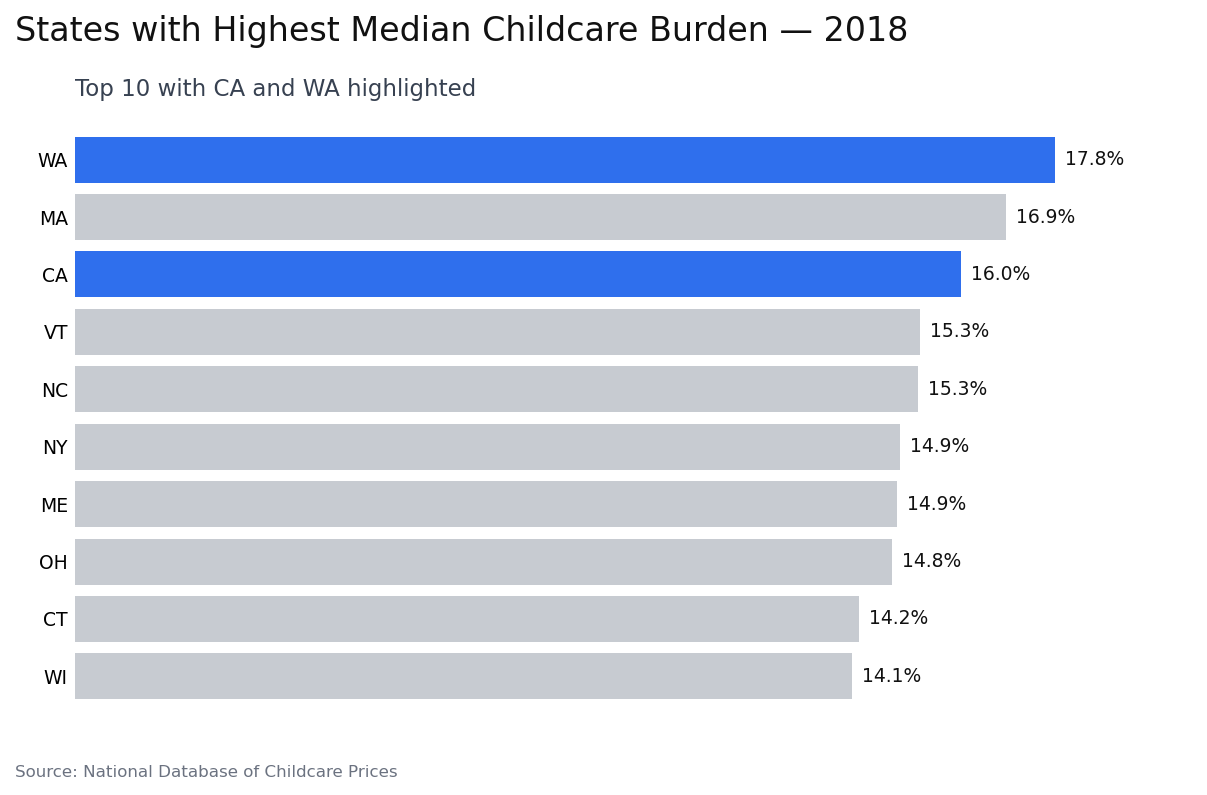

In [33]:
## States with Highest Median Childcare Burden 
state_stats = (
    base.dropna(subset=["burden"])
        .groupby("State_Abbreviation", as_index=False)
        .agg(median_burden=("burden", "median"))
)

TOP_N = 10
top_states = (state_stats
              .sort_values("median_burden", ascending=False)
              .head(TOP_N)
              .sort_values("median_burden", ascending=True)
              .reset_index(drop=True))

#highlight CA/WA
HILITE = {"CA", "WA"}
colors = [ACCENT_BLUE if s in HILITE else NEUTRAL_BAR
          for s in top_states["State_Abbreviation"]]

fig, ax = plt.subplots(figsize=(8, 5))
plt.subplots_adjust(top=0.80)

# Bars
ax.barh(top_states["State_Abbreviation"], top_states["median_burden"],
        color=colors, edgecolor="none")

#remove clutter
ax.grid(False)
for s in ax.spines.values():
    s.set_visible(False)
ax.set_xticks([]) 
ax.tick_params(axis='y', length=0) 

#add data label to bars
xmax = float(top_states["median_burden"].max())
ax.set_xlim(0, xmax * 1.14)
for y, v in enumerate(top_states["median_burden"].to_numpy()):
    ax.text(v + xmax * 0.01, y, f"{v*100:.1f}%", va="center", ha="left", fontsize=9)

#add titles
fig.suptitle(f"States with Highest Median Childcare Burden — {snapshot_year}",
             x=0.0, ha="left", fontsize=16, color=TITLE_COLOR)
ax.set_title("Top 10 with CA and WA highlighted", loc="left", fontsize=11, color="#374151", pad=6)

#source
fig.text(0.0, -0.02,
         "Source: National Database of Childcare Prices",
         ha="left", va="top", fontsize=8, color=AXIS_GRAY)

plt.tight_layout()
plt.show()

In [41]:
# Shared prep for CA & WA histograms
d_ca = base.loc[base["State_Abbreviation"]=="CA", "burden"].dropna()
d_wa = base.loc[base["State_Abbreviation"]=="WA", "burden"].dropna()

all_vals = np.concatenate([d_ca.values, d_wa.values])
xmin = float(np.floor(all_vals.min()*100)/100) - 0.01 
xmax = float(np.ceil (all_vals.max()*100)/100) + 0.01
bins = np.linspace(xmin, xmax, 20)

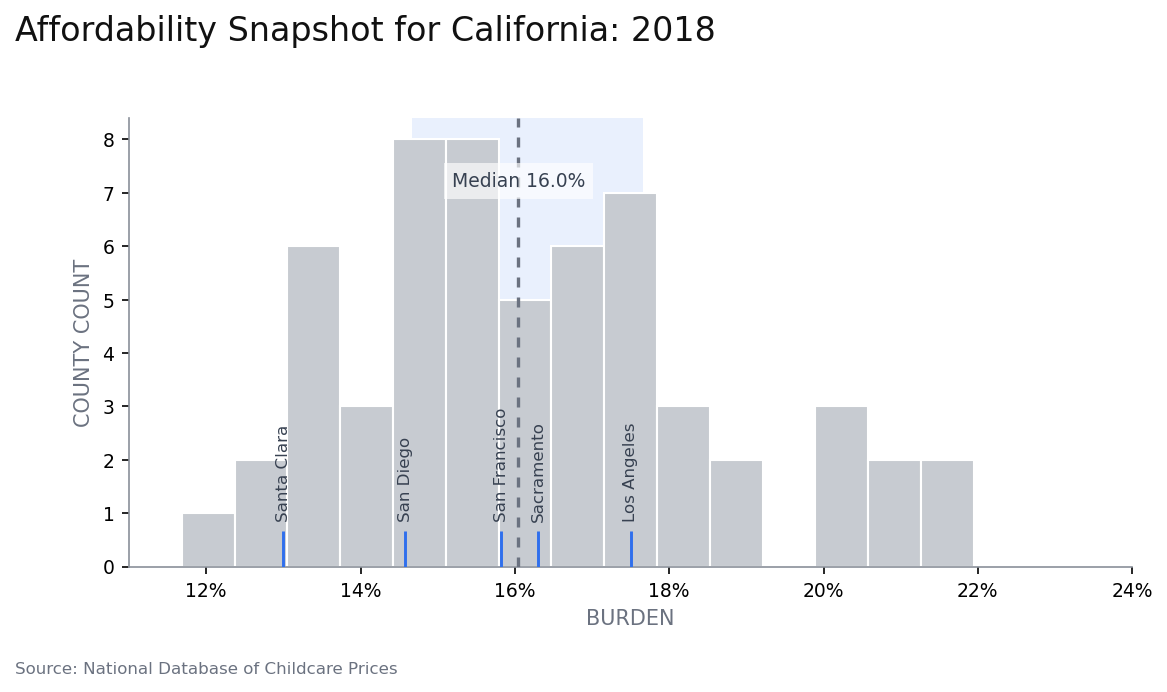

In [57]:
# CA histogram
tmp = base.assign(
    County_Short=base["County_Name"].str.replace(r"( County| city| Municipality)$", "", regex=True).str.strip()
)

# Hubs to highlight (match against County_Short)
hubs_ca = [
    "Santa Clara","San Francisco", 
    "San Diego", "Los Angeles", "Sacramento"
]
label_subset_ca = {"Santa Clara", "Los Angeles", "San Francisco", "San Diego", "Sacramento"}  # annotate only these

hub_ca = (tmp.query("State_Abbreviation == 'CA' and County_Short in @hubs_ca")
             .loc[:, ["County_Short", "burden"]]
             .dropna()
             .drop_duplicates("County_Short"))

# Compute quartiles for CA
q25, med, q75 = np.quantile(d_ca, [0.25, 0.50, 0.75])

fig, ax = plt.subplots(figsize=(7.6, 4.6))

# Histogram
ax.hist(d_ca, bins=bins, color=NEUTRAL_BAR, edgecolor="white")

# IQR band + median
ax.axvspan(q25, q75, color=ACCENT_BLUE, alpha=0.10, lw=0, zorder=0)
ax.axvline(med, color="#6B7280", lw=1.6, ls=(0, (3,3)), zorder=3)
ax.text(med, ax.get_ylim()[1]*0.86, f"Median {med*100:.1f}%",
        ha="center", va="center", fontsize=9, color="#374151",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.65))

#short ticks for hubs
ymax = ax.get_ylim()[1]
rug_h = ymax * 0.08
for _, r in hub_ca.iterrows():
    ax.vlines(r["burden"], 0, rug_h, color=ACCENT_BLUE, lw=1.4, zorder=4)
    if r["County_Short"] in label_subset_ca:
        ax.text(r["burden"], rug_h + ymax*0.02, r["County_Short"],
                ha="center", va="bottom", rotation=90, fontsize=8, color="#374151")

# Axes & styling
ax.set_xlim(xmin, xmax)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))
ax.set_xlabel("BURDEN", color=AXIS_GRAY)
ax.set_ylabel("COUNTY COUNT", color=AXIS_GRAY)
ax.grid(False)

# Title + source
fig.suptitle(f"Affordability Snapshot for California: {snapshot_year}",
             x=0.0, ha="left", fontsize=16)
fig.text(0.0, 0.02,
         "Source: National Database of Childcare Prices",
         ha="left", va="bottom", fontsize=8, color=AXIS_GRAY)

plt.subplots_adjust(top=0.83, bottom=0.18, left=0.10, right=0.98)
plt.show()

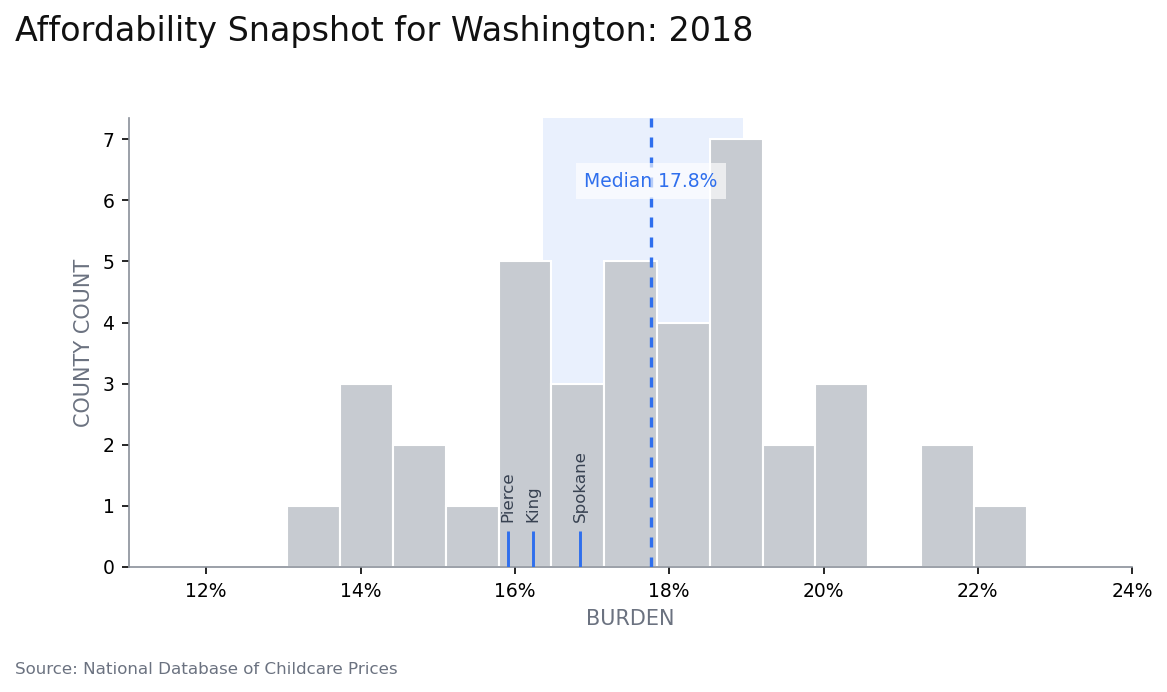

In [61]:
# Hubs to highlight (match against County_Short)
hubs_wa = ["King", "Pierce", "Spokane"]
label_subset_wa = {"King", "Spokane", "Pierce"} 

hub_wa = (tmp.query("State_Abbreviation == 'WA' and County_Short in @hubs_wa")
            .loc[:, ["County_Short", "burden"]]
            .dropna()
            .drop_duplicates("County_Short"))

# Quartiles for WA
q25, med, q75 = np.quantile(d_wa, [0.25, 0.50, 0.75])

fig, ax = plt.subplots(figsize=(7.6, 4.6))

# Histogram
ax.hist(d_wa, bins=bins, color=NEUTRAL_BAR, edgecolor="white")

# IQR band + median
ax.axvspan(q25, q75, color=ACCENT_BLUE, alpha=0.10, lw=0, zorder=0)
ax.axvline(med, color=ACCENT_BLUE, lw=1.6, ls=(0, (3,3)), zorder=3)
ax.text(med, ax.get_ylim()[1]*0.86, f"Median {med*100:.1f}%",
        ha="center", va="center", fontsize=9, color=ACCENT_BLUE,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.65))

# Rug ticks for hubs
ymax = ax.get_ylim()[1]
rug_h = ymax * 0.08
for _, r in hub_wa.iterrows():
    ax.vlines(r["burden"], 0, rug_h, color=ACCENT_BLUE, lw=1.4, zorder=4)
    if r["County_Short"] in label_subset_wa:
        ax.text(r["burden"], rug_h + ymax*0.02, r["County_Short"],
                ha="center", va="bottom", rotation=90, fontsize=8, color="#374151")

# Axes & styling
ax.set_xlim(xmin, xmax)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))
ax.set_xlabel("BURDEN", color=AXIS_GRAY)
ax.set_ylabel("COUNTY COUNT", color=AXIS_GRAY)
ax.grid(False)

# Title + source
fig.suptitle(f"Affordability Snapshot for Washington: {snapshot_year}",
             x=0.0, ha="left", fontsize=16)
fig.text(0.0, 0.02,
         "Source: National Database of Childcare Prices",
         ha="left", va="bottom", fontsize=8, color=AXIS_GRAY)

plt.subplots_adjust(top=0.83, bottom=0.18, left=0.10, right=0.98)
plt.show()

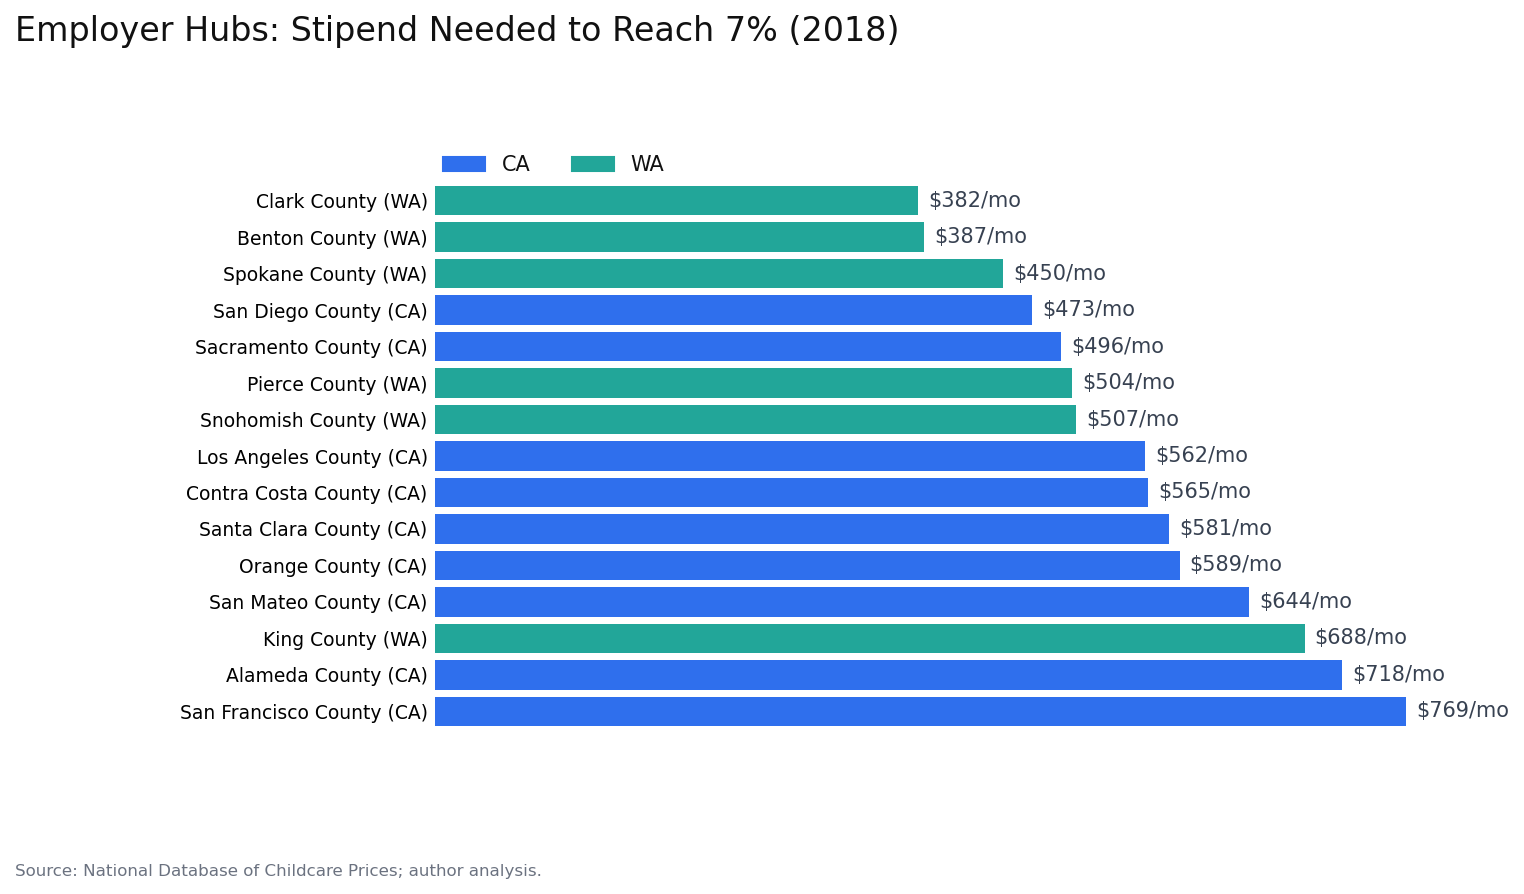

In [83]:
import matplotlib.patches as mpatches

# Your hub lists (dict) -> long DataFrame of {County_Name, State_Abbreviation}
hub_pairs = [(c, "CA") for c in df_hubs["CA"]] + [(c, "WA") for c in df_hubs["WA"]]
hubs = pd.DataFrame(hub_pairs, columns=["County_Name", "State_Abbreviation"])

# --- 1) Compute stipend needed (per month) for selected year & hubs ---
base = (df_raw.loc[df_raw["StudyYear"] == year,
                 ["County_Name","State_Abbreviation", price_col, income_col]]
          .dropna())
base["annual_price"] = base[price_col] * 52
# employer contribution needed to bring burden down to 7%
base["stipend_month"] = np.maximum(0, base["annual_price"] - AFFORD * base[income_col]) / 12

# Attach stipend to hubs and build a label
plot_df = (hubs.merge(base, on=["County_Name","State_Abbreviation"], how="left")
                .assign(label=lambda d: d["County_Name"] + " (" + d["State_Abbreviation"] + ")")
                [["label","State_Abbreviation","stipend_month"]]
                .dropna(subset=["stipend_month"])
                .sort_values("stipend_month", ascending=False)
          )

# --- 2) Plot (clean, Cole-style) ---
WA_COLOR = "#22A699"             # muted WA color to pair with your accent blue
CA_COLOR = ACCENT_BLUE           # reuse your accent blue

plot_df["color"] = np.where(plot_df["State_Abbreviation"]=="CA", CA_COLOR, WA_COLOR)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_df["label"], plot_df["stipend_month"],
        color=plot_df["color"], edgecolor="none")

# Value labels
for y, v in zip(plot_df["label"], plot_df["stipend_month"]):
    ax.text(v + 8, y, f"${v:,.0f}/mo", va="center", ha="left",
            fontsize=10, color="#374151")

#declutter
ax.grid(False)
ax.set_xlabel("")
ax.set_xticks([])
ax.tick_params(axis="y", length=0)
ax.set_ylabel("")
for s in ["top","right","bottom","left"]:
    ax.spines[s].set_visible(False)

# Title + left-aligned legend under title
fig.suptitle(f"Employer Hubs: Stipend Needed to Reach 7% ({year})",
             x=0.0, ha="left", fontsize=16)

handles = [mpatches.Patch(color=CA_COLOR, label="CA"),
           mpatches.Patch(color=WA_COLOR, label="WA")]
ax.legend(handles=handles, frameon=False, ncol=2,
          loc="upper left", bbox_to_anchor=(0.0, 1.02), borderaxespad=0.0)

# Source line
fig.text(0.0, 0.02,
         "Source: National Database of Childcare Prices; author analysis.",
         ha="left", va="bottom", fontsize=8, color=AXIS_GRAY)

plt.subplots_adjust(top=0.82, left=0.28, right=0.96, bottom=0.16)
plt.show()

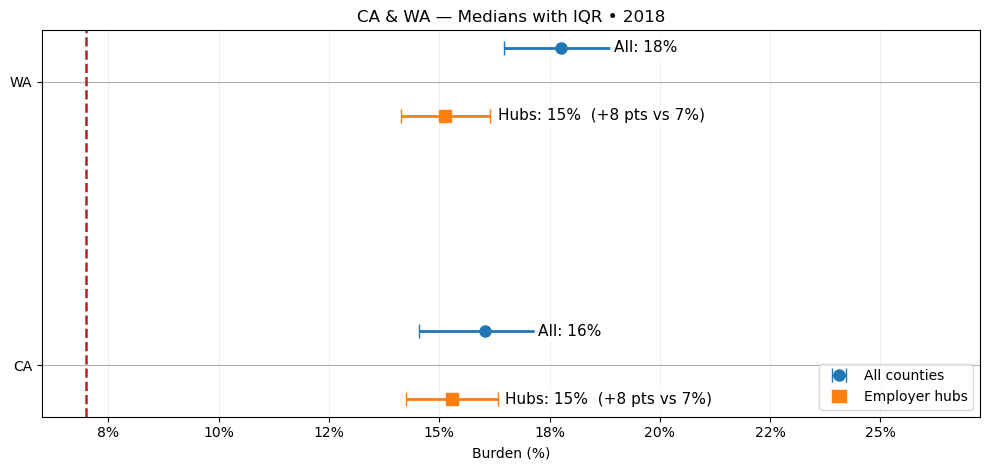

In [108]:
#Show All counties vs the Hubs where the corporate offices are located

#employer hubs you used earlier
HUBS = {
    "CA": ["Santa Clara County","San Mateo County","San Francisco County","Alameda County",
           "Contra Costa County","Los Angeles County","Orange County","San Diego County","Sacramento County"],
    "WA": ["King County","Snohomish County","Pierce County","Spokane County","Clark County","Benton County"],
}

# Build arrays for "all counties" and "hub counties" from `base`
state_all, state_hubs = {}, {}
for s in states:
    all_arr = base.loc[base["State_Abbreviation"]==s, "burden"].dropna().values
    hub_arr = base.loc[(base["State_Abbreviation"]==s) &
                       (base["County_Name"].isin(HUBS[s])), "burden"].dropna().values
    state_all[s], state_hubs[s] = all_arr, hub_arr

#medians and IQR
def med_iqr(arr):
    if arr.size == 0:
        return np.nan, 0.0
    m = np.median(arr)*100
    q25, q75 = np.quantile(arr, [0.25, 0.75])*100
    return m, (q75 - q25)/2 

med_all  = []; iqr_all = []; med_h  = []; iqr_h = []
for s in states:
    mA, iA = med_iqr(state_all[s]); med_all.append(mA); iqr_all.append(iA)
    mH, iH = med_iqr(state_hubs[s]); med_h.append(mH);   iqr_h.append(iH)

y = np.arange(len(states))

plt.figure(figsize=(10, 4.8))
ax = plt.gca()

#plot markers with error bars
a = ax.errorbar(med_all,  y+0.12, xerr=iqr_all,  fmt="o", ms=8, lw=2, capsize=5, label="All counties")
h = ax.errorbar(med_h,    y-0.12, xerr=iqr_h,    fmt="s", ms=8, lw=2, capsize=5, label="Employer hubs")

# 7% benchmark
ax.axvline(AFFORD*100, linestyle="--", color="firebrick", lw=1.8)

#axis/labels
ax.set_yticks(y); ax.set_yticklabels(states)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set_xlabel("Burden (%)")
ax.set_title(f"CA & WA — Medians with IQR • {snapshot_year}")
ax.grid(axis="x", alpha=0.2)
ax.legend(loc="lower right")

#add room on the right for annotations
xmin = min(AFFORD*100 - 1, np.nanmin(med_all) - 2)
xmax = max(np.nanmax(med_all)+max(iqr_all or [0]),
           np.nanmax(med_h)+max(iqr_h or [0])) + 8
ax.set_xlim(xmin, xmax)

for yi, (mA, mH, iA, iH) in enumerate(zip(med_all, med_h, iqr_all, iqr_h)):
    pad = 1.2  
    ax.text(mA + pad, yi+0.12, f"All: {mA:.0f}%",
            va="center", ha="left", fontsize=11,
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.9))

    gap = mH - AFFORD*100
    ax.text(mH + pad, yi-0.12, f"Hubs: {mH:.0f}%  (+{gap:.0f} pts vs 7%)",
            va="center", ha="left", fontsize=11,
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.9))

plt.tight_layout()
plt.show()

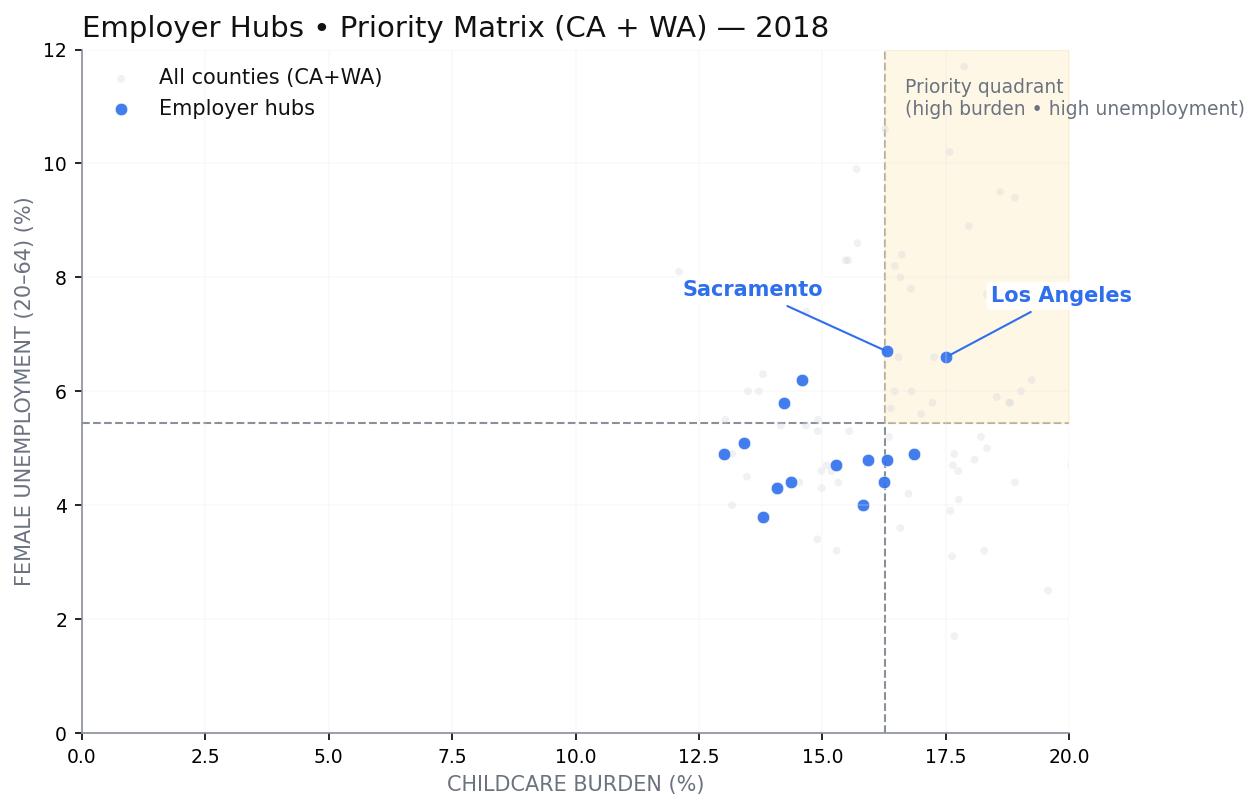

In [121]:
from matplotlib.ticker import FuncFormatter
import matplotlib.patches as mpatches



# 1) CA+WA slice + percent fields
ca_wa = base[base["State_Abbreviation"].isin(["CA","WA"])].copy()
u = pd.to_numeric(ca_wa["FUNR_20to64"], errors="coerce")
ca_wa["unemp_pct"]  = np.where(u.max(skipna=True) <= 1.5, u*100, u)
ca_wa["burden_pct"] = ca_wa["burden"]*100

ca_hubs = [
    "Santa Clara County","San Mateo County","San Francisco County","Alameda County",
    "Contra Costa County","Los Angeles County","Orange County","San Diego County","Sacramento County"
]
wa_hubs = ["King County","Snohomish County","Pierce County","Spokane County","Clark County","Benton County"]
hub_names = set(ca_hubs + wa_hubs)
hubs = ca_wa[ca_wa["County_Name"].isin(hub_names)].copy()

# Thresholds from hubs
x_thr = hubs["burden_pct"].quantile(0.75)
y_thr = hubs["unemp_pct"].quantile(0.75)
x_max, y_max = 20, 12
x_thr_plot = min(x_thr, x_max)
y_thr_plot = min(y_thr, y_max)

# Label only the high•high hubs (top up to 5 by combined rank)
prio = hubs[(hubs["burden_pct"] >= x_thr) & (hubs["unemp_pct"] >= y_thr)].copy()
if not prio.empty:
    prio["score"] = (prio["burden_pct"].rank(pct=True) + prio["unemp_pct"].rank(pct=True))/2
    label_df = prio.nlargest(min(5, len(prio)), "score")
else:
    label_df = hubs.nlargest(2, "burden_pct")

fig, ax = plt.subplots(figsize=(8.5,5.5))

# Context counties
ax.scatter(ca_wa["burden_pct"], ca_wa["unemp_pct"],
           s=14, color="#D4D7DC", alpha=0.35, edgecolor="none", label="All counties (CA+WA)")

# Hubs
ax.scatter(hubs["burden_pct"], hubs["unemp_pct"],
           s=36, color=ACCENT_BLUE, alpha=0.9, edgecolor="white", linewidth=0.3, label="Employer hubs")

# Quadrant guides & shade
ax.axvline(x_thr_plot, color=NEUTRAL_EDGE, ls="--", lw=1, zorder=0)
ax.axhline(y_thr_plot, color=NEUTRAL_EDGE, ls="--", lw=1, zorder=0)
ax.fill_betweenx([y_thr_plot, y_max], x_thr_plot, x_max, color="#FFEAB6", alpha=0.35, zorder=0)

# Move the quadrant caption higher so it doesn't clash with labels
ax.text(x_thr_plot + 0.4, y_max - 0.5,
        "Priority quadrant\n(high burden • high unemployment)",
        va="top", ha="left", fontsize=9, color=AXIS_GRAY)

# --- Label placement with offsets to avoid overlap --------------------------
# You can tune offsets here per hub if needed.
label_offsets = {
    "Sacramento County": (-1.3, 0.9, "right"),   # (dx, dy, ha)
    "Los Angeles County": ( 0.9, 0.9, "left"),
    # defaults used if a hub isn’t listed:
}
for _, r in label_df.iterrows():
    name_full = r["County_Name"]
    short = name_full.replace(" County", "")
    dx, dy, ha = label_offsets.get(name_full, (0.8, 0.8, "left"))
    ax.annotate(short,
                xy=(r["burden_pct"], r["unemp_pct"]),
                xytext=(r["burden_pct"] + dx, r["unemp_pct"] + dy),
                textcoords="data",
                ha=ha, va="bottom",
                color=ACCENT_BLUE, fontsize=10, fontweight="bold",
                arrowprops=dict(arrowstyle="-", lw=1, color=ACCENT_BLUE),
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.9),
                zorder=5)

# Axes, legend, title
ax.set_xlim(0, x_max)
ax.set_ylim(0, y_max)
ax.set_xlabel("CHILDCARE BURDEN (%)", color=AXIS_GRAY)
ax.set_ylabel("FEMALE UNEMPLOYMENT (20–64) (%)", color=AXIS_GRAY)
ax.set_title(f"Employer Hubs • Priority Matrix (CA + WA) — {snapshot_year}", loc="left")
ax.legend(loc="upper left", frameon=False)
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

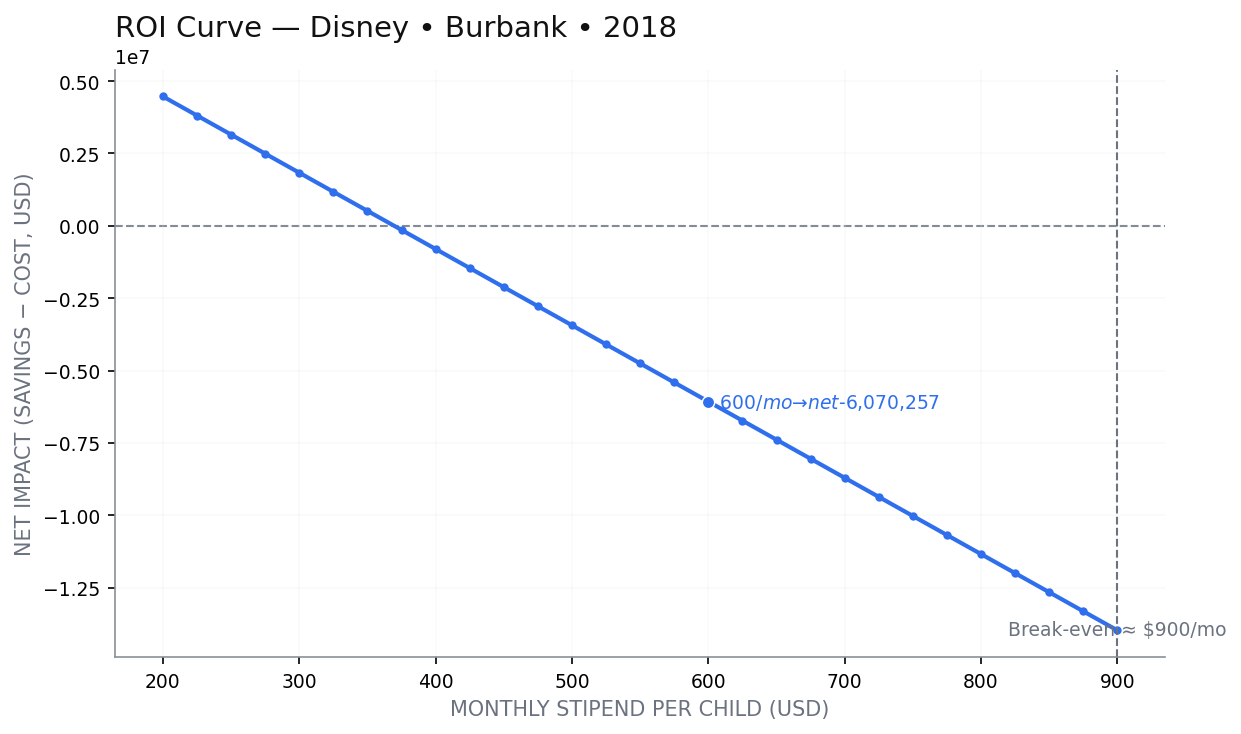

Assumptions used:
  Headcount (on-site adj.): 14,760
  Eligible parents:         2,509
  Participants (uptake):    1,756  (uptake=70%)
  Children supported:       2,196  (avg_kids=1.25)
  Replacement cost/turnover: $168,000  (×1.20 of $140,000)
  Baseline turnover:        22%
  Retention lift:           15%
  Annual savings (flat):    $9,737,703

Max stipend for net ≥ 0: ~$900/mo


In [131]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1) Pick the hub
target_employer = "Disney" 
target_site     = "Burbank"   

# 2) Load the synthetic HR site file
sites = pd.read_csv("employer_sites_hr_synthetic_showcase.csv")

# 3) Pick the row for the chosen hub (Employer + SiteName)
row = (sites
       .loc[(sites["Employer"]==target_employer) & (sites["SiteName"]==target_site)]
       .squeeze())

assert row.shape[0] > 0, "Selected employer/site not found. Check the names."

# 4) Pull inputs with safe fallbacks (units noted in comments)
headcount   = pd.to_numeric(row.get("Headcount",                20000), errors="coerce")        # people
pct_parents = pd.to_numeric(row.get("Percent_Parents_U6",          0.25), errors="coerce")     # share of employees
avg_salary  = pd.to_numeric(row.get("Avg_Salary",               150000), errors="coerce")      # $ per employee
remote_share= pd.to_numeric(row.get("Remote_Share",                 0.20), errors="coerce")    # share fully remote
avg_kids    = pd.to_numeric(row.get("Avg_Children_Per_Parent",     1.20), errors="coerce")     # children per participating parent
base_turn   = pd.to_numeric(row.get("Baseline_Turnover_Rate",      0.12), errors="coerce")     # annual turnover rate
repl_mult   = pd.to_numeric(row.get("ReplacementMultiple",         1.20), errors="coerce")     # x salary as replacement cost
lift        = pd.to_numeric(row.get("RetentionLift",               0.15), errors="coerce")     # retention lift from stipend (absolute pts)
uptake      = pd.to_numeric(row.get("UptakeRate",                  0.70), errors="coerce")     # share of eligible who enroll

# 5) Derived quantities
on_site_headcount   = headcount * (1 - remote_share)
eligible_parents    = on_site_headcount * pct_parents
participants        = eligible_parents * uptake
children_supported  = participants * avg_kids
replacement_cost    = repl_mult * avg_salary

# Assumption (transparent): incremental “saves” come from lift × baseline_turnover × participants
# Rationale: if baseline turnover is 12% and the stipend reduces turnover by +15 percentage points for participants,
# the incremental avoids ~0.12 * 0.15 * participants turnover events.
avoided_turnovers   = base_turn * lift * participants
annual_savings      = avoided_turnovers * replacement_cost  # $/year, independent of stipend amount

# 6) Stipend scenarios and net calculation
stip_grid = np.arange(200, 901, 25)  # $/mo per child
program_cost = stip_grid * 12 * children_supported
net = annual_savings - program_cost

# 7) Break-even stipend (highest stipend with net >= 0, linear interpolation)
break_even = None
if (net >= 0).any():
    # interpolate along positive segment right edge
    # find first index where net turns negative (from positive)
    sign_change_idx = np.where(np.diff(net >= 0).astype(int) == -1)[0]
    if len(sign_change_idx):
        i = sign_change_idx[0]
        x1, x2 = stip_grid[i], stip_grid[i+1]
        y1, y2 = net[i], net[i+1]
        # y = y1 + (y2 - y1) * (x - x1)/(x2 - x1) => solve for y=0
        break_even = x1 - y1 * (x2 - x1) / (y2 - y1)
    else:
        # all nonnegative
        break_even = float(stip_grid.max())
else:
    # never crosses zero; best net is at the minimum stipend
    break_even = None

# 8) Plot — ROI curve
fig, ax = plt.subplots(figsize=(8.4, 5))

ax.plot(stip_grid, net, marker="o", ms=3, lw=2, color=ACCENT_BLUE)
ax.axhline(0, color=AXIS_GRAY, lw=1, linestyle="--", zorder=0)

if break_even is not None:
    ax.axvline(break_even, color=AXIS_GRAY, lw=1, linestyle="--")
    ax.text(break_even, ax.get_ylim()[0] + 0.03*(ax.get_ylim()[1]-ax.get_ylim()[0]),
            f"Break-even ≈ ${break_even:,.0f}/mo", ha="center", va="bottom",
            fontsize=9, color=AXIS_GRAY)

# Optional: highlight a candidate stipend (e.g., 600)
candidate = 600
if stip_grid.min() <= candidate <= stip_grid.max():
    # find nearest net for marker
    idx = np.abs(stip_grid - candidate).argmin()
    ax.scatter([stip_grid[idx]], [net[idx]], s=35, color=ACCENT_BLUE, edgecolor="white", linewidth=0.7, zorder=3)
    ax.text(stip_grid[idx], net[idx],
            f"  ${candidate}/mo → net ${net[idx]:,.0f}", va="center", ha="left",
            fontsize=9, color=ACCENT_BLUE)

# Cosmetics (Cole-ish)
ax.set_title(f"ROI Curve — {target_employer} • {target_site} • {snapshot_year}", loc="left")
ax.set_xlabel("MONTHLY STIPEND PER CHILD (USD)", color=AXIS_GRAY)
ax.set_ylabel("NET IMPACT (SAVINGS − COST, USD)", color=AXIS_GRAY)
ax.grid(True, alpha=0.25)
for spine in ["top","right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

# 9) Print the key figures used (transparent assumptions)
print("Assumptions used:")
print(f"  Headcount (on-site adj.): {on_site_headcount:,.0f}")
print(f"  Eligible parents:         {eligible_parents:,.0f}")
print(f"  Participants (uptake):    {participants:,.0f}  (uptake={uptake:.0%})")
print(f"  Children supported:       {children_supported:,.0f}  (avg_kids={avg_kids:.2f})")
print(f"  Replacement cost/turnover: ${replacement_cost:,.0f}  (×{repl_mult:.2f} of ${avg_salary:,.0f})")
print(f"  Baseline turnover:        {base_turn:.0%}")
print(f"  Retention lift:           {lift:.0%}")
print(f"  Annual savings (flat):    ${annual_savings:,.0f}")
if break_even is not None:
    print(f"\nMax stipend for net ≥ 0: ~${break_even:,.0f}/mo")
else:
    print("\nNo break-even in the tested range; net is negative across all stipends.")

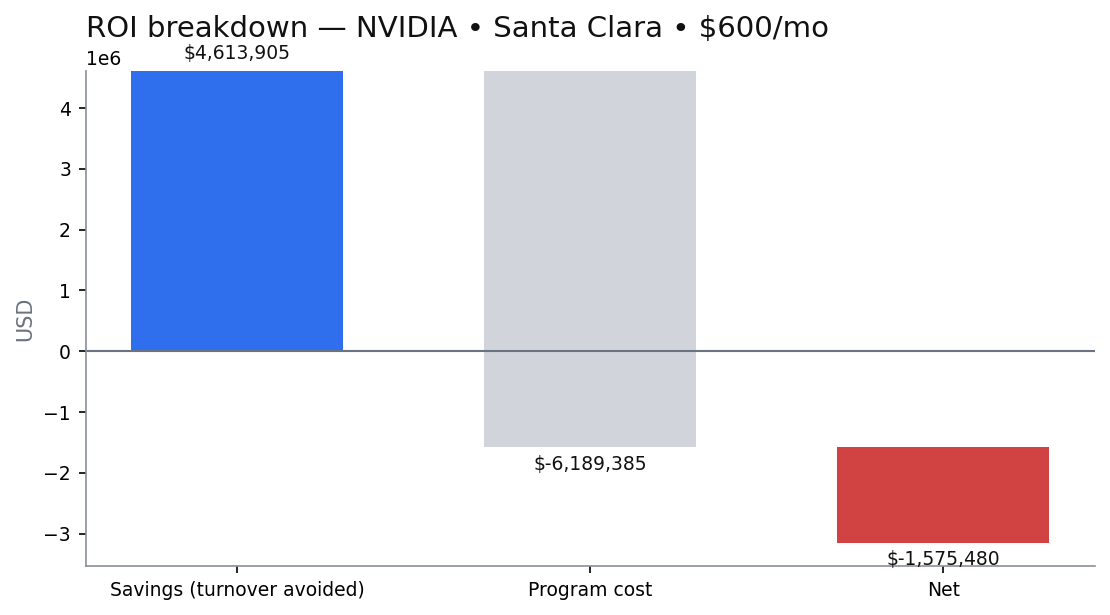

In [18]:
# Pick a single site from LA/Sacramento to explain the math
site_pick = (sub
             .assign(label=lambda d: d["Employer"]+" — "+d["SiteName"])
             .sort_values("net", ascending=False)
             .iloc[0]) 

savings  = float(site_pick["saved_turns"] * site_pick["repl_cost"])
cost     = float(target_stipend * 12 * site_pick["children"])
net      = savings - cost

steps = pd.DataFrame({
    "cat": ["Savings (turnover avoided)", "Program cost", "Net"],
    "val": [savings, -cost, net]
})

fig, ax = plt.subplots(figsize=(7.5,4.2))
cumulative = steps["val"].cumsum().shift(fill_value=0)
colors = [ACCENT_BLUE, "#D1D5DB", ACCENT_BLUE if net>=0 else "#D14343"]

for i, (cat, v, base) in enumerate(zip(steps["cat"], steps["val"], cumulative)):
    ax.bar(i, v, bottom=base, width=0.6, color=colors[i])
    ax.text(i, base + v + (0.02*np.sign(v))*max(abs(steps["val"])),
            f'${v:,.0f}', ha="center", va="bottom" if v>=0 else "top", fontsize=9, color=TITLE_COLOR)

ax.set_xticks(range(len(steps))); ax.set_xticklabels(steps["cat"])
ax.set_ylabel("USD", color=AXIS_GRAY); ax.set_title(f"ROI breakdown — {site_pick['Employer']} • {site_pick['SiteName']} • ${target_stipend}/mo", loc="left")
ax.axhline(0, color=AXIS_GRAY, lw=1); ax.grid(False)
for s in ["top","right"]: ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

NameError: name 'snapshot_year' is not defined

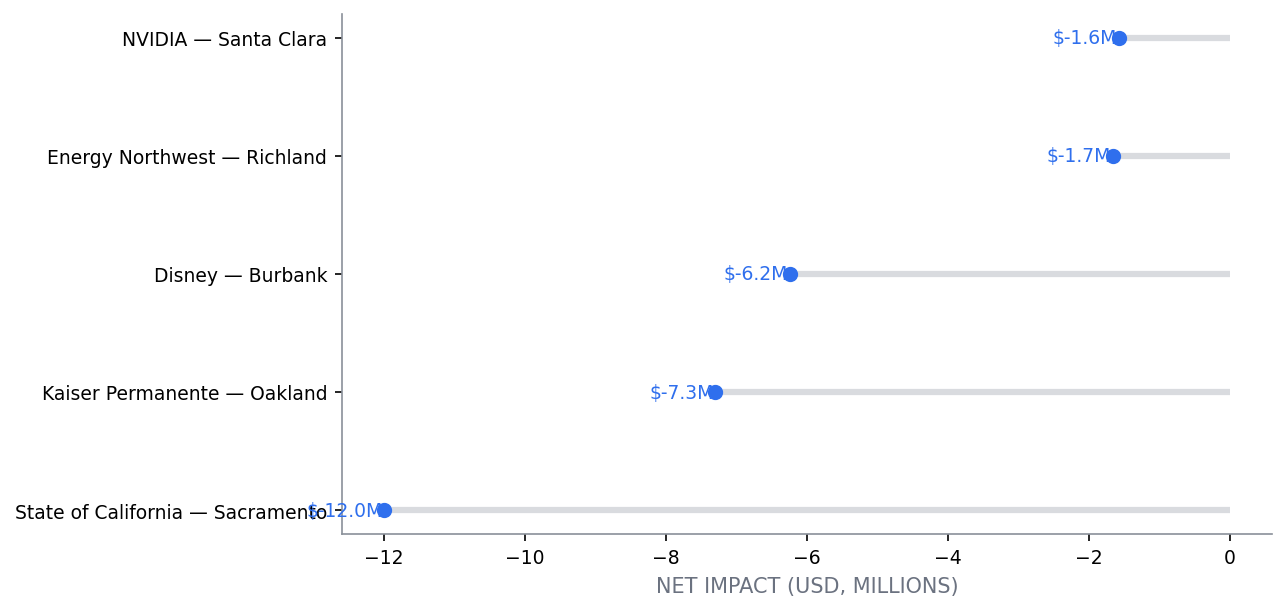

In [12]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, re

# Reload sites if needed
sites = pd.read_csv("employer_sites_hr_synthetic_showcase.csv")

# --- choose stipend & geography ---
target_stipend = 600   # $/mo per child
mask_LA  = sites.get("County_Name","").astype(str).str.contains("Los Angeles", case=False, na=False) | sites["SiteName"].str.contains("Los Angeles|LA", case=False, na=False)
mask_SAC = sites.get("County_Name","").astype(str).str.contains("Sacramento",  case=False, na=False) | sites["SiteName"].str.contains("Sacramento",  case=False, na=False)
sub = sites[mask_LA | mask_SAC].copy()
assert len(sub)>0, "No rows matched Los Angeles or Sacramento. Check names in the CSV."

# Pull inputs (same math you used)
def to_num(s, default=0): 
    return pd.to_numeric(s, errors="coerce").fillna(default)

sub["on_site"]     = to_num(sub["Headcount"]) * (1 - to_num(sub["Remote_Share"]))
sub["eligible"]    = sub["on_site"] * to_num(sub["Percent_Parents_U6"])
sub["participants"]= sub["eligible"] * to_num(sub["Uptake_Rate"], 0.70)
sub["children"]    = sub["participants"] * to_num(sub["Avg_Children_Per_Parent"], 1.2)
sub["repl_cost"]   = to_num(sub["ReplacementMultiple"], 1.2) * to_num(sub["Avg_Salary"], 150000)
sub["saved_turns"] = to_num(sub["Baseline_Turnover_Rate"], 0.12) * to_num(sub["Retention_Lift_If_Stipend"], 0.15) * sub["participants"]

annual_savings     = sub["saved_turns"] * sub["repl_cost"]
program_cost       = target_stipend * 12 * sub["children"]
sub["net"]         = annual_savings - program_cost

# Rank & plot
show = (sub
        .assign(label=lambda d: d["Employer"]+" — "+d["SiteName"])
        .sort_values("net", ascending=False)
        .head(7))

y = np.arange(len(show))[::-1]  # top at top
fig, ax = plt.subplots(figsize=(8,4.5))
ax.hlines(y, 0, show["net"]/1e6, color=AXIS_GRAY, lw=3, alpha=0.25)  # stems
ax.scatter(show["net"]/1e6, y, s=40, color=ACCENT_BLUE, zorder=3)

for xi, yi, v in zip(show["net"]/1e6, y, show["net"]):
    ax.text(xi + (0.02 if xi>=0 else -0.02), yi,
            f'${v/1e6:,.1f}M', va="center", ha="left" if xi>=0 else "right", color=ACCENT_BLUE, fontsize=9)

ax.set_yticks(y)
ax.set_yticklabels(show["label"])
ax.set_xlabel("NET IMPACT (USD, MILLIONS)", color=AXIS_GRAY)
ax.set_title(f"Top 7 employer hubs by net impact @ ${target_stipend}/mo • LA & Sacramento • {snapshot_year}", loc="left")
ax.axvline(0, color=AXIS_GRAY, lw=1)
ax.grid(False)
for s in ["top","right"]: ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

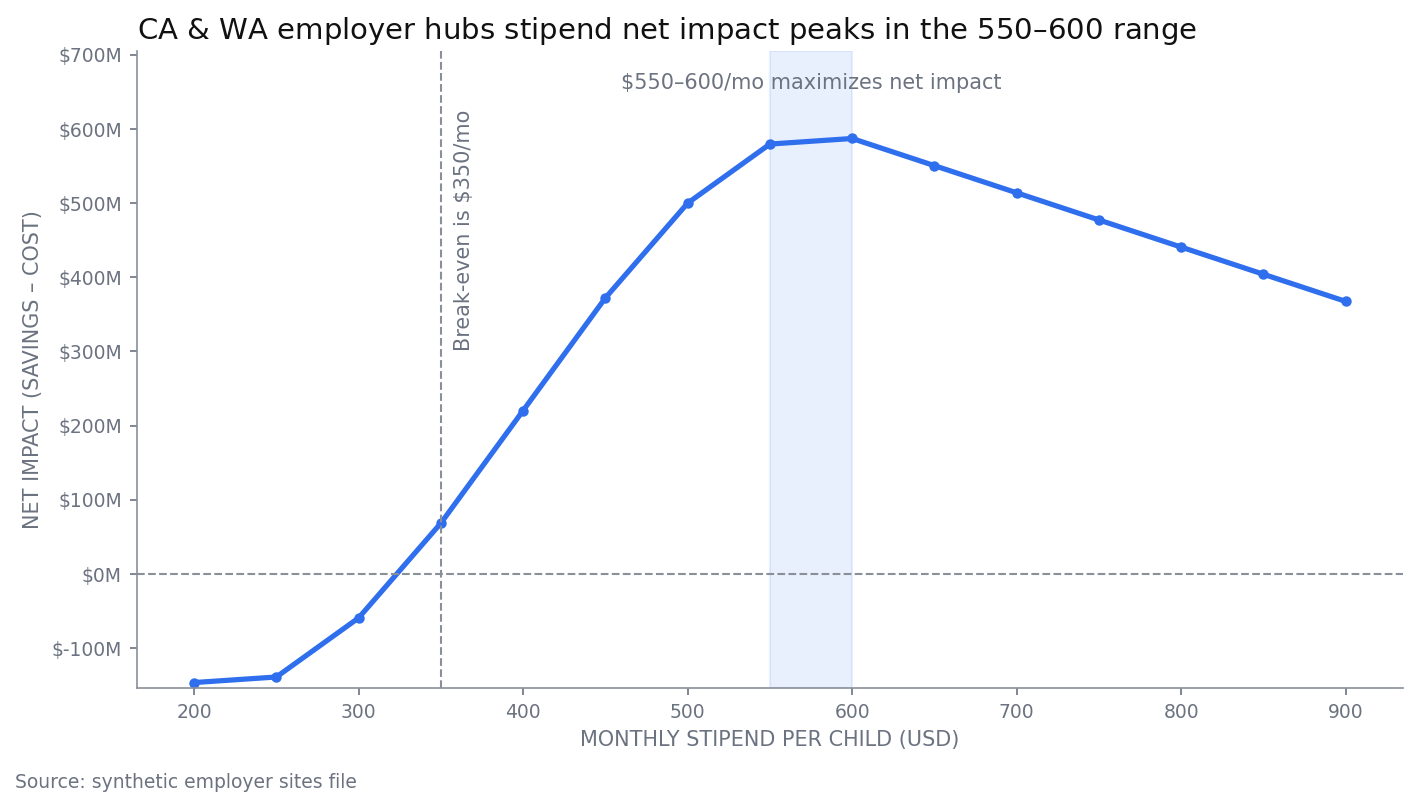

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# include some assumptions
replacement_multiple = 1.20
uptake = 0.70
kids_per_parent = 1.2
lift_max = 0.15 

#Smooth stipend
def lift_from_stipend(s, s0=200, s_mid=600, lift_max=0.15):
    s = np.asarray(s, dtype=float)
    x = (s - s0) / (s_mid - s0)
    x = np.clip(x, 0, 1)
    return lift_max * (3*x**2 - 2*x**3)

#Filter to CA & WA
sites_hubs = sites.query("State_Abbreviation in ['CA','WA']").copy()

# Participants & children
parents = sites_hubs["Headcount"] * sites_hubs["Percent_Parents_U6"]
children = (sites_hubs["Children_Supported"]
            if "Children_Supported" in sites_hubs.columns
            else parents * kids_per_parent)

#Replacement cost per parent
replacement_cost = sites_hubs["Avg_Salary"] * replacement_multiple

#get ROI across a stipend grid
stipend_grid = np.arange(200, 925, 50)
net = []
for s in stipend_grid:
    lift = lift_from_stipend(s, s0=200, s_mid=600, lift_max=lift_max)  # <- key
    retained_parents = parents * uptake * lift
    savings = (retained_parents * replacement_cost).sum()
    program_cost = (children.sum() * s * 12.0)
    net.append(savings - program_cost)
net = np.array(net)

#plot
def fmt_millions(v, _):
    return f"${v/1e6:,.0f}M"

# break-even (first stipend where net ≥ 0)
be_idx = np.argmax(net >= 0) if np.any(net >= 0) else None

# peak within the full grid and within the [500, 600] highlight band
peak_idx_all = int(np.argmax(net))
peak_x_all, peak_y_all = stipend_grid[peak_idx_all], net[peak_idx_all]

fig, ax = plt.subplots(figsize=(9.5, 5.2))

ax.grid(axis="y", visible =False)
ax.grid(axis="x", visible=False)

# shade the sweet-spot band and annotate
ax.axvspan(550, 600, color=ACCENT_BLUE, alpha=0.10, zorder=0)


# main line
ax.plot(stipend_grid, net, color=ACCENT_BLUE, lw=2.5, marker="o", ms=4)
ymin, ymax = ax.get_ylim()
yr = (ymax - ymin)

mid_x = 575  # midpoint of 550–600
mid_y = np.interp(mid_x, stipend_grid, net)          # y on the curve at 575
offset = 0.08 * yr                                   # vertical gap above the line
ax.text(mid_x, mid_y + offset,
        "$550–600/mo maximizes net impact",
        ha="center", va="bottom", color=AXIS_GRAY)

if be_idx is not None:
    be_x = stipend_grid[be_idx]
    ax.text(be_x + 8, ymin + 0.6*yr,                 # high on the axis
            f"Break-even is ${be_x:.0f}/mo",
            rotation=90, ha="left", va="bottom", color=AXIS_GRAY)

# break-even line 
if be_idx is not None and net[be_idx] >= 0:
    ax.axvline(stipend_grid[be_idx], color=NEUTRAL_EDGE, ls="--", lw=1)


# zero line
ax.axhline(0, color=NEUTRAL_EDGE, ls="--", lw=1)

# axes, ticks, limits
ax.set_ylabel("NET IMPACT (SAVINGS – COST)", color=AXIS_GRAY)
ax.set_xlabel("MONTHLY STIPEND PER CHILD (USD)", color=AXIS_GRAY)
ax.yaxis.set_major_formatter(FuncFormatter(fmt_millions)) 
ax.tick_params(axis="x", colors=AXIS_GRAY)
ax.tick_params(axis="y", colors=AXIS_GRAY)

# keep a little headroom; never crop negatives
ymin = min(0, net.min()*1.05)
ymax = net.max()*1.2
ax.set_ylim(ymin, ymax)

# descriptive, left-aligned title with takeaway
ax.set_title(
    "CA & WA employer hubs stipend net impact peaks in the $550–$600 range",
    loc="left"
)

# source line
fig.text(0.01, -0.02,
         "Source: synthetic employer sites file",
         color=AXIS_GRAY, fontsize=9)

plt.tight_layout()
plt.show()

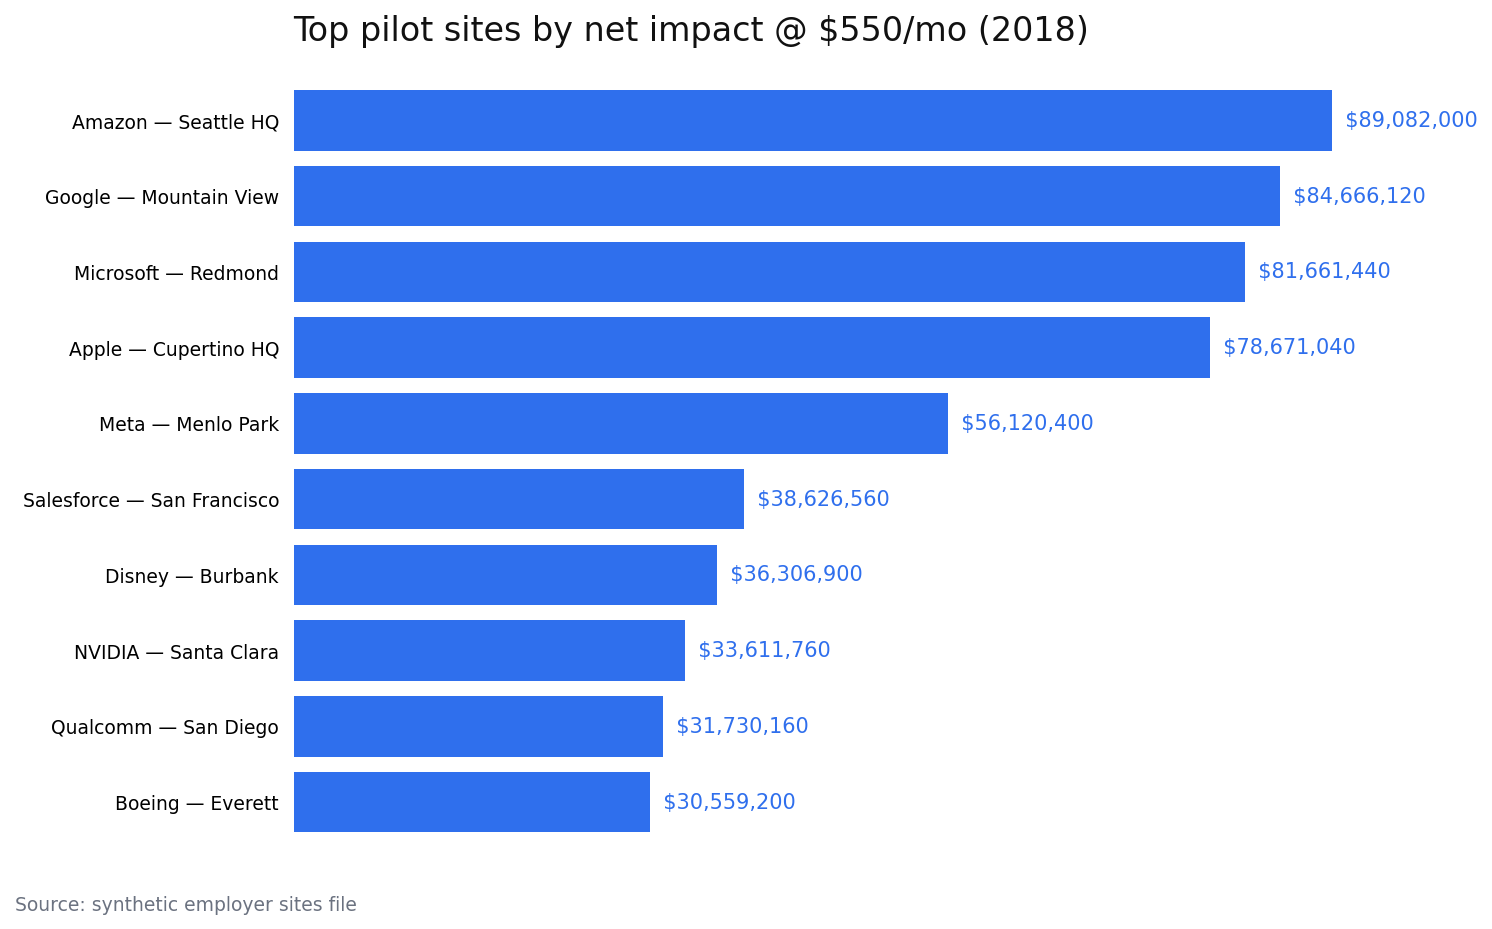

In [92]:

sites = pd.read_csv("employer_sites_hr_synthetic_showcase.csv")

def num(x):  # robust numeric cast
    return pd.to_numeric(x, errors="coerce")

for c in ["Headcount","Percent_Parents_U6","Avg_Salary",
          "Avg_Children_Per_Parent","Remote_Share"]:
    if c in sites.columns:
        sites[c] = num(sites[c])

#percent-like columns: if given as 20 not 0.20, scale down
for pc in ["Percent_Parents_U6","Remote_Share"]:
    if pc in sites.columns:
        sites[pc] = sites[pc].where(sites[pc].isna() | (sites[pc] <= 1), sites[pc]/100.0)

#Assumptions and per-site net at stipend S
S = 550  # monthly stipend per child (USD)
UPTAKE = 0.70
RETENTION_LIFT = 0.15
REPLACEMENT_MULTIPLE = 1.20

#fallbacks
if "Avg_Children_Per_Parent" not in sites.columns:
    sites["Avg_Children_Per_Parent"] = 1.20
if "Remote_Share" not in sites.columns:
    sites["Remote_Share"] = 0.0

eligible_parents = sites["Headcount"] * (1 - sites["Remote_Sare"].fillna(0)) if "Remote_Sare" in sites.columns else sites["Headcount"]
eligible_parents = eligible_parents * sites["Percent_Parents_U6"].fillna(0.16)

#program cost = children * stipend * 12
children = eligible_parents * sites["Avg_Children_Per_Parent"].fillna(1.2) * UPTAKE
program_cost = children * S * 12

#savings = participants * (avg_salary * replacement_multiple * retention_lift)
participants = eligible_parents * UPTAKE
savings = participants * sites["Avg_Salary"].fillna(150_000) * REPLACEMENT_MULTIPLE * RETENTION_LIFT

net_site = savings - program_cost

#Build display Site label
site_lbl = (
    sites.get("Employer","").astype(str).str.strip()
    + " — "
    + sites.get("Site", sites.get("SiteName", sites.get("County_Name",""))).astype(str).str.strip()
)

roi_sites = pd.DataFrame({
    "Site": site_lbl.str.replace(r" — \s*—\s*", " — ", regex=True),
    "State": sites.get("State_Abbreviation",""),
    "Net":   pd.to_numeric(net_site, errors="coerce")
}).dropna(subset=["Net"])

#Top N positive net (guard against empty / all non-positive)
N = 10
pos = roi_sites.query("Net > 0").copy()
if pos.empty:
    # if no positives, just take the top N (may be negative) to avoid NaN max
    topN = roi_sites.sort_values("Net", ascending=False).head(N)
else:
    topN = pos.sort_values("Net", ascending=False).head(N)

#plot
accent = ACCENT_BLUE if "ACCENT_BLUE" in globals() else "#2F6FED"

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(topN["Site"], topN["Net"], color=accent, edgecolor="none")
ax.invert_yaxis()

#end labels
for y, v in enumerate(topN["Net"].to_numpy()):
    ax.text(v, y, f"  ${v:,.0f}", va="center", ha="left", color=accent)

#safe x-limits
xmax = float(topN["Net"].max())
xmin = 0.0 if xmax > 0 else float(topN["Net"].min()) * 1.05
ax.set_xlim(xmin, xmax * 1.12 if np.isfinite(xmax) else 1)

#de-clutter
ax.set_title("Top pilot sites by net impact @ $550/mo (2018)", loc="left")
ax.grid(False)
ax.set_xlabel(""); ax.set_ylabel("")
ax.set_xticks([])
ax.tick_params(axis="y", left=False)
for spine in ["top","right","bottom","left"]:
    ax.spines[spine].set_visible(False)

#source line
fig.text(0.01, -0.02,
         "Source: synthetic employer sites file",
         color=AXIS_GRAY, fontsize=9)

plt.tight_layout()
plt.show()

In [22]:
sites = pd.read_csv("employer_sites_hr_synthetic_showcase.csv", dtype={"County_FIPS_Code": str})
sites["County_FIPS_Code"] = sites["County_FIPS_Code"].str.zfill(5)

sites = sites.merge(
    county[["County_FIPS_Code","annual_price","income","burden","stipend_needed_month"]],
    on="County_FIPS_Code", how="left"
)

#check data
sites[["Employer","SiteName","State_Abbreviation","County_Name","stipend_needed_month","burden"]].head(8)

NameError: name 'county' is not defined

In [150]:
#Define function to run scenarios.

def run_scenario(sites_df: pd.DataFrame,
                 stipend_month: float,
                 scale_retention_by_fraction: bool = True,
                 cap_at_needed: bool = True,
                 adjust_for_remote: bool = True):
    """
    Returns:
      site_view  : per-site metrics
      emp_view   : per-employer aggregated metrics
      overall    : overall sums (Series)
    """
    s = sites_df.copy()

    #eligible parents & participation
    s["eligible_parents"] = s["Headcount"] * s["Percent_Parents_U6"]
    eff_uptake = s["Uptake_Rate"] * (1 - s["Remote_Share"]) if adjust_for_remote else s["Uptake_Rate"]
    s["participants"] = s["eligible_parents"] * eff_uptake
    s["children_supported"] = s["participants"] * s["Avg_Children_Per_Parent"]

    #stipend paid
    need = s["stipend_needed_month"].fillna(stipend_month)
    s["stipend_paid"] = np.minimum(stipend_month, need) if cap_at_needed else stipend_month

    #Annual cost
    s["program_cost"] = s["children_supported"] * s["stipend_paid"] * 12.0

    #Retention savings from avoided turnover from parents
    frac = (s["stipend_paid"] / s["stipend_needed_month"].replace(0, np.nan)).clip(upper=1.0)
    frac = frac.fillna(1.0)
    lift = s["Retention_Lift_If_Stipend"] * (frac if scale_retention_by_fraction else 1.0)
    s["turnover_avoided"] = s["eligible_parents"] * s["Baseline_Turnover_Rate"] * lift
    s["savings_turnover"] = s["turnover_avoided"] * s["Cost_Per_Turnover"]

    #calculate net
    s["net_impact"] = s["savings_turnover"] - s["program_cost"]

    emp = (s.groupby("Employer", as_index=False)
             .agg(program_cost=("program_cost","sum"),
                  savings=("savings_turnover","sum"),
                  net=("net_impact","sum"),
                  employees=("Headcount","sum"),
                  parents=("eligible_parents","sum"),
                  participants=("participants","sum"),
                  children=("children_supported","sum")))

    overall = emp[["program_cost","savings","net","participants","children"]].sum(numeric_only=True)
    return s, emp, overall

In [152]:
stipend_grid = np.arange(200, 901, 50) 
rows = []

for val in stipend_grid:
    _, _, overall = run_scenario(sites, stipend_month=val)
    rows.append({"stipend_month": val,
                 "program_cost": overall["program_cost"],
                 "savings": overall["savings"],
                 "net": overall["net"],
                 "participants": overall["participants"],
                 "children": overall["children"]})

roi = pd.DataFrame(rows)

#fidn break-even closest to zero net
break_even_row = roi.iloc[(roi["net"]).abs().argmin()]
break_even = float(break_even_row["stipend_month"])
break_even_row

stipend_month    2.000000e+02
program_cost     7.956014e+07
savings          9.145554e+07
net              1.189541e+07
participants     2.829247e+04
children         3.315006e+04
Name: 0, dtype: float64

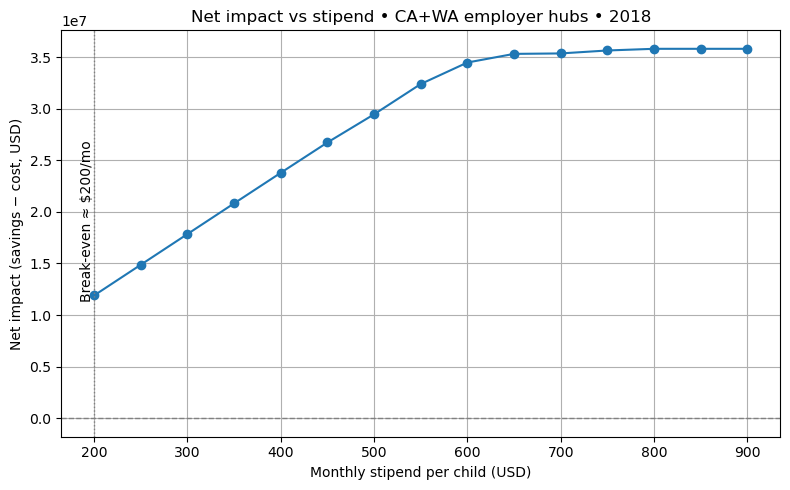

In [154]:
# Plot ROI curve
plt.figure(figsize=(8,5))
plt.plot(roi["stipend_month"], roi["net"], marker="o")
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.axvline(break_even, color="gray", linestyle=":", linewidth=1)
plt.text(break_even, roi["net"].min()*0.95, f"Break-even ≈ ${break_even:,.0f}/mo",
         rotation=90, va="bottom", ha="right")
plt.title(f"Net impact vs stipend • CA+WA employer hubs • {snapshot_year}")
plt.xlabel("Monthly stipend per child (USD)")
plt.ylabel("Net impact (savings − cost, USD)")
plt.tight_layout(); plt.show()

In [162]:
candidate_stipend = 600

site_view, emp_view, overall = run_scenario(sites, stipend_month=candidate_stipend)

sv = site_view.copy()
sv["children"] = sv["children_supported"]
sv["impact_per_100k"] = sv["net_impact"] / 100_000.0

top_sites = (sv.sort_values(["net_impact","participants"], ascending=[False, False])
               [["Employer","SiteName","State_Abbreviation","County_Name",
                 "participants","children","program_cost","savings_turnover",
                 "net_impact","impact_per_100k","stipend_paid","stipend_needed_month"]]
               .head(12))

top_sites.style.format({
    "participants":"{:.0f}", "children":"{:.0f}",
    "program_cost":"${:,.0f}", "savings_turnover":"${:,.0f}",
    "net_impact":"${:,.0f}", "impact_per_100k":"{:+.2f}x",
    "stipend_paid":"${:,.0f}/mo", "stipend_needed_month":"${:,.0f}/mo"
})

,Employer,SiteName,State_Abbreviation,County_Name,participants,children,program_cost,savings_turnover,net_impact,impact_per_100k,stipend_paid,stipend_needed_month
1,Google,Mountain View,CA,Santa Clara County,1939,2133,"$14,868,016","$26,658,720","$11,790,704",+117.91x,$581/mo,$581/mo
0,Apple,Cupertino HQ,CA,Santa Clara County,2040,2244,"$15,645,429","$23,647,680","$8,002,251",+80.02x,$581/mo,$581/mo
4,Meta,Menlo Park,CA,San Mateo County,1138,1252,"$9,015,494","$16,541,353","$7,525,859",+75.26x,$600/mo,$644/mo
8,Qualcomm,San Diego,CA,San Diego County,969,1066,"$6,050,922","$10,602,900","$4,551,978",+45.52x,$473/mo,$473/mo
14,Microsoft,Redmond,WA,King County,2322,2555,"$18,393,661","$22,104,811","$3,711,150",+37.11x,$600/mo,$688/mo
2,NVIDIA,Santa Clara,CA,Santa Clara County,781,860,"$5,992,924","$9,564,480","$3,571,556",+35.72x,$581/mo,$581/mo
9,Oracle,Redwood Shores,CA,San Mateo County,525,578,"$4,160,471","$7,337,633","$3,177,162",+31.77x,$600/mo,$644/mo
5,Salesforce,San Francisco,CA,San Francisco County,788,867,"$6,240,707","$9,167,268","$2,926,561",+29.27x,$600/mo,$769/mo
13,Amazon,Seattle HQ,WA,King County,3100,3410,"$24,548,832","$27,386,662","$2,837,830",+28.38x,$600/mo,$688/mo
6,Uber,San Francisco HQ,CA,San Francisco County,431,474,"$3,412,886","$5,603,155","$2,190,269",+21.90x,$600/mo,$769/mo


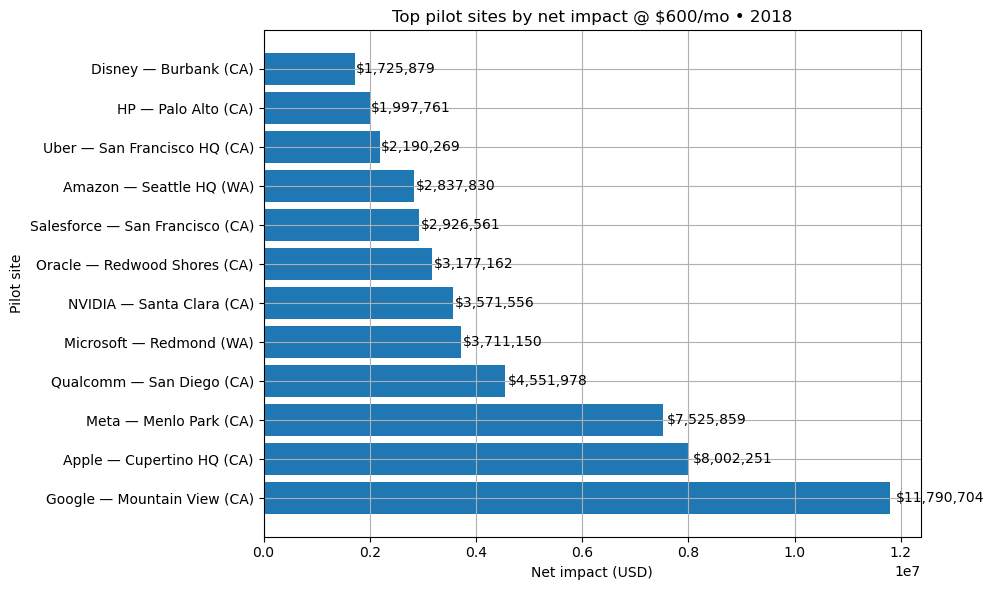

In [164]:
ts = top_sites.copy()
ts["label"] = ts["Employer"] + " — " + ts["SiteName"] + " (" + ts["State_Abbreviation"] + ")"

plt.figure(figsize=(10,6))
bars = plt.barh(ts["label"], ts["net_impact"])
plt.xlabel("Net impact (USD)"); plt.ylabel("Pilot site")
plt.title(f"Top pilot sites by net impact @ ${candidate_stipend:,.0f}/mo • {snapshot_year}")
for b in bars:
    w = b.get_width(); y = b.get_y() + b.get_height()/2
    plt.text(w*1.01, y, f"${w:,.0f}", va="center")
plt.tight_layout(); plt.show()

In [168]:
# If you used `sites_story` above keep it; else use `sites`
sites_for_story = globals().get("sites_story", sites)

site_view, emp_view, overall = run_scenario(sites_for_story, stipend_month=candidate_stipend)

tot = overall.copy()
tot["roi_ratio"] = tot["savings"] / tot["program_cost"]
print(f"Recommended stipend: ${candidate_stipend:,.0f}/mo")
print(f"Program cost:        ${tot['program_cost']:,.0f}")
print(f"Savings (retention): ${tot['savings']:,.0f}")
print(f"Net impact:          ${tot['net']:,.0f}")
print(f"ROI (savings/cost):  {tot['roi_ratio']:.2f}x")
print(f"Participants (parents): {tot['participants']:,.0f}   Children: {tot['children']:,.0f}")

Recommended stipend: $600/mo
Program cost:        $224,260,377
Savings (retention): $258,727,910
Net impact:          $34,467,533
ROI (savings/cost):  1.15x
Participants (parents): 28,292   Children: 33,150


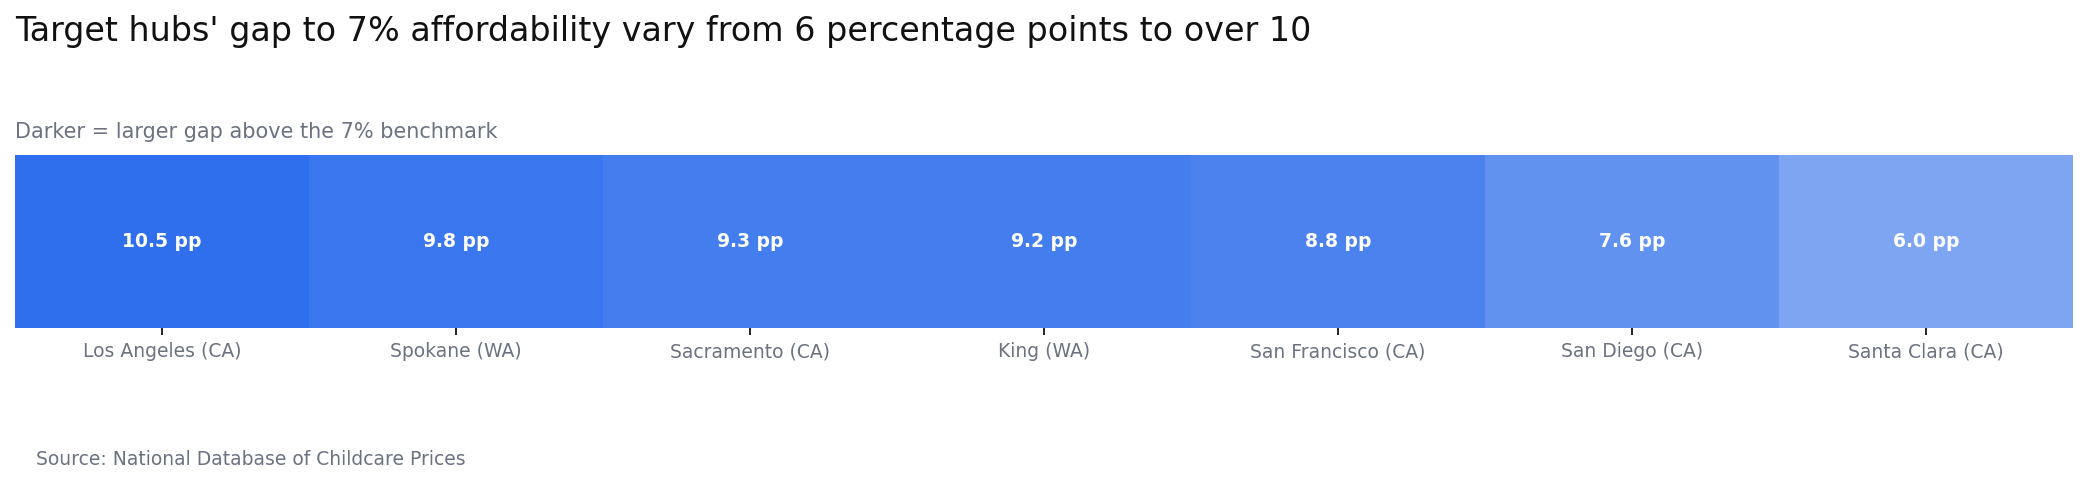

In [160]:
#Single-row heatmap for a specific short-list of hubs
import re, numpy as np, pandas as pd, matplotlib.pyplot as plt, matplotlib.colors as mcolors

#Preconditions
assert "base" in globals() and isinstance(base, pd.DataFrame), "Expected a DataFrame `base`."
assert {"County_Name","State_Abbreviation","burden"}.issubset(base.columns), \
       "`base` must have County_Name, State_Abbreviation, burden."

AFFORD       = globals().get("AFFORD", 0.07)
ACCENT_BLUE  = globals().get("ACCENT_BLUE",  "#2F6FED")
AXIS_GRAY    = globals().get("AXIS_GRAY",    "#6B7280")

#target list (county + state)
targets = [
    ("Los Angeles County",  "CA"),
    ("Sacramento County",   "CA"),
    ("San Francisco County","CA"),
    ("San Diego County",    "CA"),
    ("Santa Clara County",  "CA"),
    ("King County",         "WA"),
    ("Spokane County",      "WA"),
]
hubs = pd.DataFrame(targets, columns=["County_Name","State_Abbreviation"])

# 2) Normalize names to avoid tiny mismatches (e.g., extra spaces / case)
def norm_county(s):
    s = (str(s) if pd.notna(s) else "").strip().lower()
    s = re.sub(r"\s+county$", "", s)     # drop trailing " county"
    s = re.sub(r"\s+", " ", s)           # collapse whitespace
    return s

hubs["_key"] = hubs["County_Name"].map(norm_county) + "|" + hubs["State_Abbreviation"].str.upper()
base["_key"] = base["County_Name"].map(norm_county) + "|" + base["State_Abbreviation"].str.upper()

# 3) Merge to get burden; show any that didn’t match so you know why
merged = hubs.merge(base[["_key","County_Name","State_Abbreviation","burden"]],
                    on="_key", how="left", suffixes=("","_base"))

unmatched = merged[merged["burden"].isna()][["County_Name","State_Abbreviation"]]
if len(unmatched):
    print("Not found in `base`")
    display(unmatched)

# Keep only matched
hub_gap = (merged.dropna(subset=["burden"])
                 .assign(gap_pp=lambda d: np.clip((d["burden"] - AFFORD)*100, 0, None))
                 .assign(label=lambda d: d["County_Name"].str.replace(" County","", regex=False)
                                         + " (" + d["State_Abbreviation"] + ")")
                 .sort_values("gap_pp", ascending=False)
                 .reset_index(drop=True))

# 4) Plot single-row heatmap
vals = hub_gap["gap_pp"].to_numpy()[None, :]
n = vals.shape[1]
if n == 0:
    raise ValueError("No hubs matched with valid burden values; fix names or year coverage and re-run.")

cmap = mcolors.LinearSegmentedColormap.from_list("gapblue", ["#E7EEF9", ACCENT_BLUE])
vmin, vmax = 0, max(1.0, float(np.nanmax(vals)))
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

fig_w = max(11, 0.65*n)
fig, ax = plt.subplots(figsize=(14, 1.5))
fig.subplots_adjust(left=0, right=0.98)

im = ax.imshow(vals, aspect="auto", cmap=cmap, norm=norm)

# Clean style
ax.set_yticks([])
ax.set_xticks(np.arange(n))
ax.set_xticklabels(hub_gap["label"], rotation=0, ha="center", color=AXIS_GRAY, fontsize=9)
for sp in ax.spines.values(): sp.set_visible(False)

# In-cell labels
for j, v in enumerate(hub_gap["gap_pp"].to_numpy()):
    txt_color = "white" if norm(v) > 0.55 else "#222"
    ax.text(j, 0, f"{v:.1f} pp", va="center", ha="center", fontsize=9, color=txt_color, fontweight="bold")


# Titles & source (left-aligned)
fig.suptitle("Target hubs' gap to 7% affordability vary from 6 percentage points to over 10", x=0.0, y=1.5, ha="left", fontsize=16)
ax.set_title("Darker = larger gap above the 7% benchmark", loc="left", color=AXIS_GRAY, fontsize=10, pad=8)
fig.text(0.01, -0.5, "Source: National Database of Childcare Prices", color=AXIS_GRAY, fontsize=9)


plt.show()


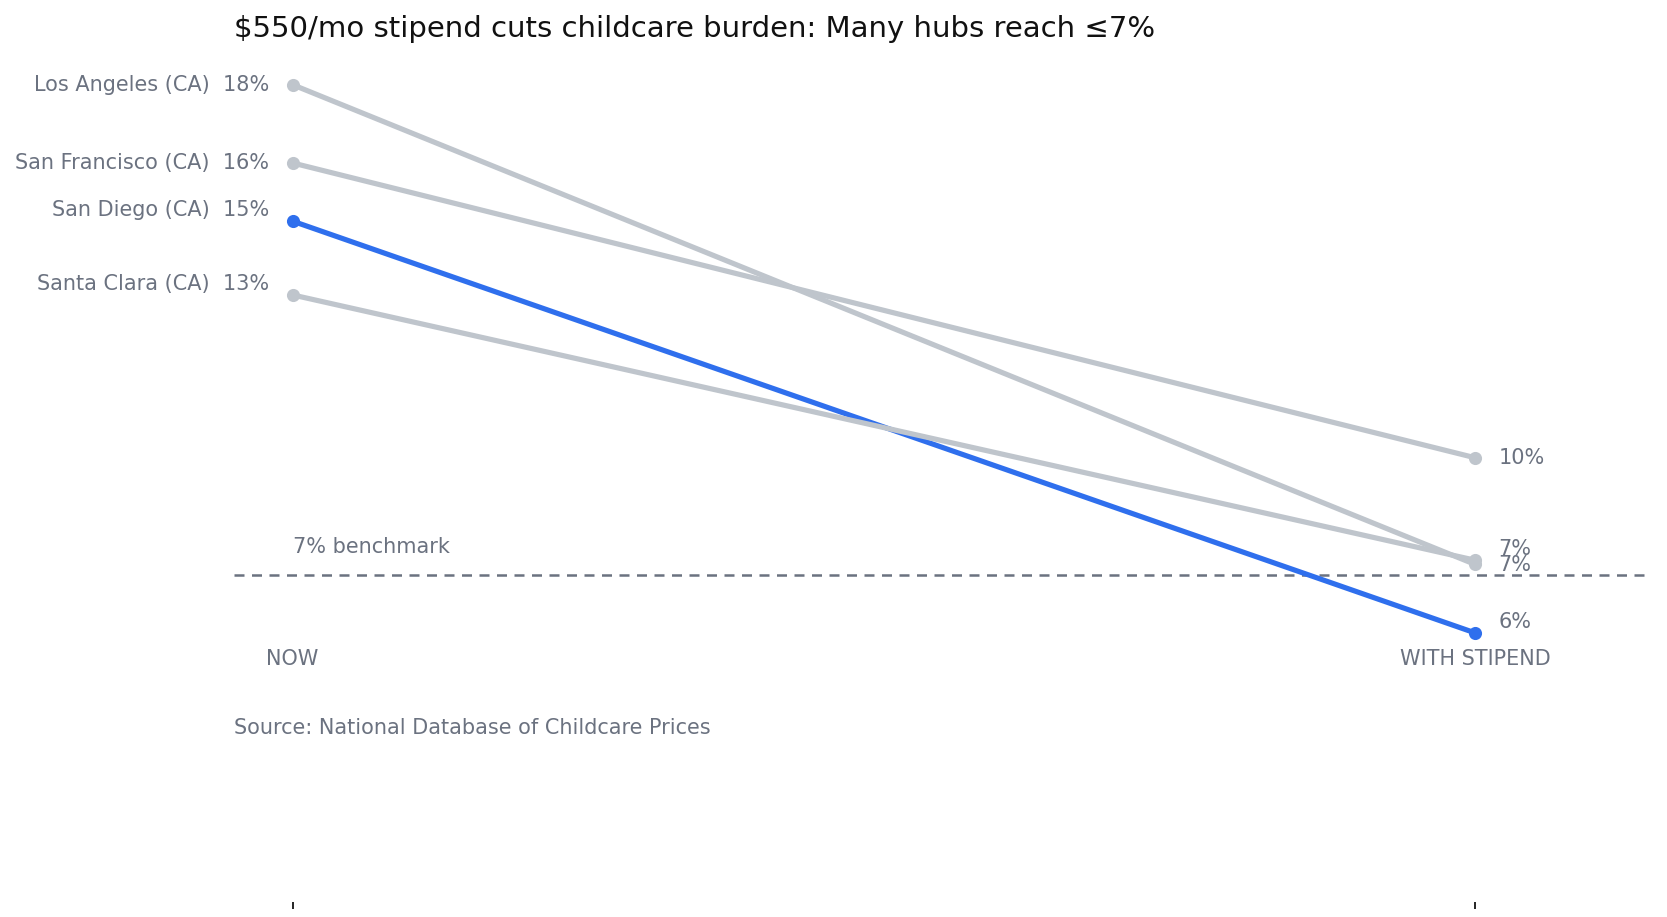

In [208]:
# --- INPUTS you can tweak ---
stipend_amt = 550          # monthly stipend per child (USD)
AFFORD = 0.07              # 7% benchmark
targets = [
    "Los Angeles County","San Francisco County",
    "San Diego County","Santa Clara County"
]

# --- Build hub table: now vs after stipend ---
hubs_now = (base.loc[base["County_Name"].isin(targets) & base["State_Abbreviation"].isin(["CA","WA"]),
                     ["County_Name","State_Abbreviation","annual_price","income","burden"]]
            .copy())

# Burden AFTER stipend: (annual_price - 12 * stipend) / income
hubs_now["annual_after"] = (hubs_now["annual_price"] - 12*stipend_amt).clip(lower=0)
hubs_now["burden_after"] = hubs_now["annual_after"] / hubs_now["income"]

# Labels & order
hubs_now["hub"] = hubs_now["County_Name"].str.replace(" County","", regex=False) \
                    + " (" + hubs_now["State_Abbreviation"] + ")"
hubs_now["delta_pp"] = (hubs_now["burden"] - hubs_now["burden_after"]) * 100
hubs_now = hubs_now.sort_values("delta_pp", ascending=False).reset_index(drop=True)

# Which hubs cross the 7% line AFTER the stipend?
hubs_now["hits_7"] = hubs_now["burden_after"] <= AFFORD
n_hits = int(hubs_now["hits_7"].sum())

# --- Plot: slopegraph ---
import matplotlib.pyplot as plt
import numpy as np

accent = ACCENT_BLUE if 'ACCENT_BLUE' in globals() else "#2F6FED"
neutral = AXIS_GRAY if 'AXIS_GRAY' in globals() else "#6B7280"

fig, ax = plt.subplots(figsize=(11,6), constrained_layout=True)

x0, x1 = 0, 1
y_min = 0
y_max = max( (hubs_now["burden"].max()*100), (hubs_now["burden_after"].max()*100), 18 ) 

# Draw each line (now -> after). Color accent if it reaches ≤7%, else neutral gray
for i, r in hubs_now.iterrows():
    y_now   = r["burden"]*100
    y_after = r["burden_after"]*100
    col = accent if r["hits_7"] else "#BFC5CC"  # light gray for non-hits
    ax.plot([x0, x1], [y_now, y_after], color=col, linewidth=2.5, zorder=2)
    ax.scatter([x0, x1], [y_now, y_after], color=col, s=28, zorder=3)

    # Direct labels at the ends (stagger slightly to reduce overlap)
    dy = (i % 2) * 0.25  # tiny vertical stagger
    ax.text(x0 - 0.02, y_now + dy, f"{r['hub']}  {y_now:.0f}%", ha="right", va="center", color=neutral)
    ax.text(x1 + 0.02, y_after + dy, f"{y_after:.0f}%", ha="left", va="center", color=neutral)

# 7% benchmark line
ax.axhline(AFFORD*100, color=neutral, linestyle=(0,(4,3)), linewidth=1.2, zorder=1)
ax.text(x0, AFFORD*100+0.4, "7% benchmark", color=neutral, fontsize=10, va="bottom")

# Hide default tick labels
ax.set_xticks([x0, x1])
ax.set_xticklabels([])

# Put custom labels near the 7% benchmark
label_y = AFFORD*100 + -2  
ax.text(x0, label_y, "NOW",           ha="center", va="bottom", color=AXIS_GRAY)
ax.text(x1, label_y, "WITH STIPEND",  ha="center", va="bottom", color=AXIS_GRAY)

# Title / subtitle with takeaway
ax.set_title(
    f"${stipend_amt}/mo stipend cuts childcare burden: Many hubs reach ≤7%",
    loc="left", pad=12
)

# Clean up axes
ax.set_xlim(-0.05, 1.15)
ax.set_ylim(y_min, y_max)
ax.tick_params(axis='y', length=0, labelleft=False)
for spine in ["top","right","left","bottom"]:
    ax.spines[spine].set_visible(False)

# Source note
ax.text(0, 0.2, "Source: National Database of Childcare Prices",
        transform=ax.transAxes, color=neutral, fontsize=10)

plt.show()


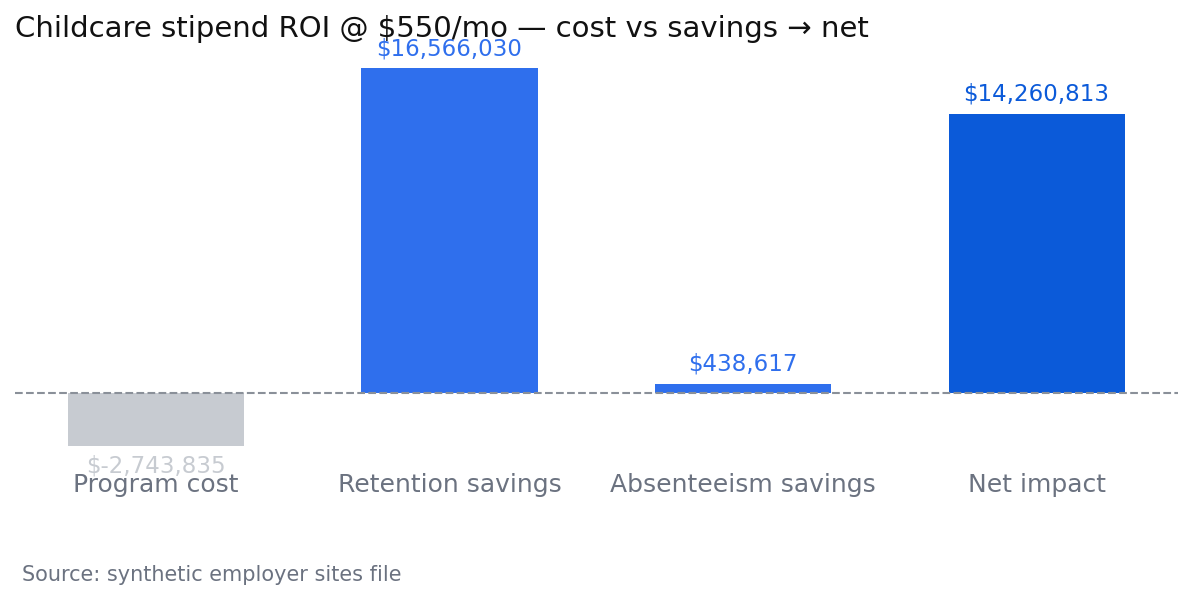

In [220]:
# --- Employer-centric ROI waterfall • $550/mo ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 0) Inputs / assumptions (edit as needed)
STIPEND = 550                                # monthly per child
PCT_PARENTS = 0.35                           # if Percent_Parents_* not in file
UPTAKE = 0.70                                # if not in file
RETENTION_LIFT = 0.15                        # incremental reduction in quits for participants
TURNOVER_MULT = 1.20                         # replacement cost ≈ 1.2 × salary if not in file
CHILDREN_PER_PARENT = 1.2                    # avg children per eligible parent in program
ABS_DAYS_SAVED = 2                           # days saved per participating parent/year if not in file

# Style (Cole-inspired)
ACCENT = "#2F6FED"       # savings / positive
NEG    = "#C7CBD1"       # cost (neutral gray)
NET    = "#0B5AD9"       # net bar (darker accent)
AXIS   = "#6B7280"
EDGE   = "#8A9099"
plt.rcParams.update({
    "figure.dpi":150, "axes.spines.top":False, "axes.spines.right":False,
    "axes.edgecolor":EDGE, "axes.titlelocation":"left",
})

# 1) Load employer sites file
sites = pd.read_csv("employer_sites_hr_synthetic_showcase.csv")

# 2) Build the quantities we need, falling back to assumptions when columns are missing
hc   = sites.get("Headcount", pd.Series([1000]*len(sites))).astype(float)
sal  = sites.get("Avg_Salary", pd.Series([120000]*len(sites))).astype(float)
ppct = (sites["Percent_Parents_U6"].astype(float)/100
        if "Percent_Parents_U6" in sites.columns
        else pd.Series([PCT_PARENTS]*len(sites)))
upt  = (sites["Uptake"].astype(float)/100
        if "Uptake" in sites.columns
        else pd.Series([UPTAKE]*len(sites)))
rlft = (sites["Retention_Lift"].astype(float)/100
        if "Retention_Lift" in sites.columns
        else pd.Series([RETENTION_LIFT]*len(sites)))
tvm  = (sites["ReplacementMultiple"].astype(float)
        if "ReplacementMultiple" in sites.columns
        else pd.Series([TURNOVER_MULT]*len(sites)))
kids = (sites["Avg_Children_Per_Parent"].astype(float)
        if "Avg_Children_Per_Parent" in sites.columns
        else pd.Series([CHILDREN_PER_PARENT]*len(sites)))
abs_days = (sites["Absence_Days_Saved"].astype(float)
            if "Absence_Days_Saved" in sites.columns
            else pd.Series([ABS_DAYS_SAVED]*len(sites)))

# participants = eligible parents * uptake
participants = (hc * ppct * upt).sum()

# Children supported
children = (participants * kids.mean())

# Program cost (USD / year)
program_cost = children * STIPEND * 12

# Retention savings (USD / year) ≈ headcount * baseline quits reduced * cost per turnover
# If Baseline_Turnover_Rate column exists, use it; else use 0.15
base_quit = (sites["Baseline_Turnover_Rate"].astype(float)/100
             if "Baseline_Turnover_Rate" in sites.columns
             else pd.Series([0.15]*len(sites)))
retention_sav = (hc * base_quit * rlft * (tvm * sal)).sum()

# Absenteeism savings (USD / year) ≈ participants * days_saved * salary/day
salary_per_day = (sal / 260)                 # ~workdays/year
abs_sav = ( (hc * ppct * upt) * abs_days * salary_per_day ).sum()

total_savings = retention_sav + abs_sav
net = total_savings - program_cost

# 3) Assemble the waterfall data
steps = pd.DataFrame({
    "label": ["Program cost", "Retention savings", "Absenteeism savings", "Net impact"],
    "value": [-program_cost,  retention_sav,        abs_sav,               net]
})

# 4) Plot
# Assemble steps (uses variables computed earlier)
steps = pd.DataFrame({
    "label": ["Program cost", "Retention savings", "Absenteeism savings", "Net impact"],
    "value": [-program_cost,  retention_sav,        abs_sav,               net]
})

ACCENT = "#2F6FED"       # savings / positive
NEG    = "#C7CBD1"       # cost (neutral gray)
NETCOL = "#0B5AD9"       # net bar (darker accent)
AXIS   = "#6B7280"
EDGE   = "#8A9099"

fig, ax = plt.subplots(figsize=(10, 4.2))

# Bars
for i, (lab, val) in enumerate(zip(steps["label"], steps["value"])):
    color = NETCOL if lab == "Net impact" else (ACCENT if val > 0 else NEG)
    ax.bar(i, val, color=color, width=0.6)
    # value labels (a little offset from the bar end)
    off = 0.025 * (np.nanmax(np.abs(steps["value"])) or 1.0)
    ax.text(i, val + (off if val >= 0 else -off),
            f"${val:,.0f}", ha="center",
            va="bottom" if val >= 0 else "top",
            color=color, fontsize=11, clip_on=False)

# Zero baseline
ax.axhline(0, color=EDGE, lw=1, ls="--")

# X labels
ax.set_xticks(range(len(steps)))
ax.set_xticklabels(steps["label"], color=AXIS, fontsize=12)

# Remove y ticks/labels and BOTH axis lines (spines)
ax.set_yticks([])
for s in ax.spines.values():
    s.set_visible(False)
ax.tick_params(axis="x", length=0)   # no tick marks

# Title
ax.set_title("Childcare stipend ROI @ $550/mo — cost vs savings → net", loc="left")

# Make room for the source and place it at the figure level (so it never overlaps)
fig.subplots_adjust(bottom=0.22)  # extra margin
fig.text(0.13, 0.03, "Source: synthetic employer sites file",
        ha="left", va="bottom", color=AXIS, fontsize=10)

plt.show()


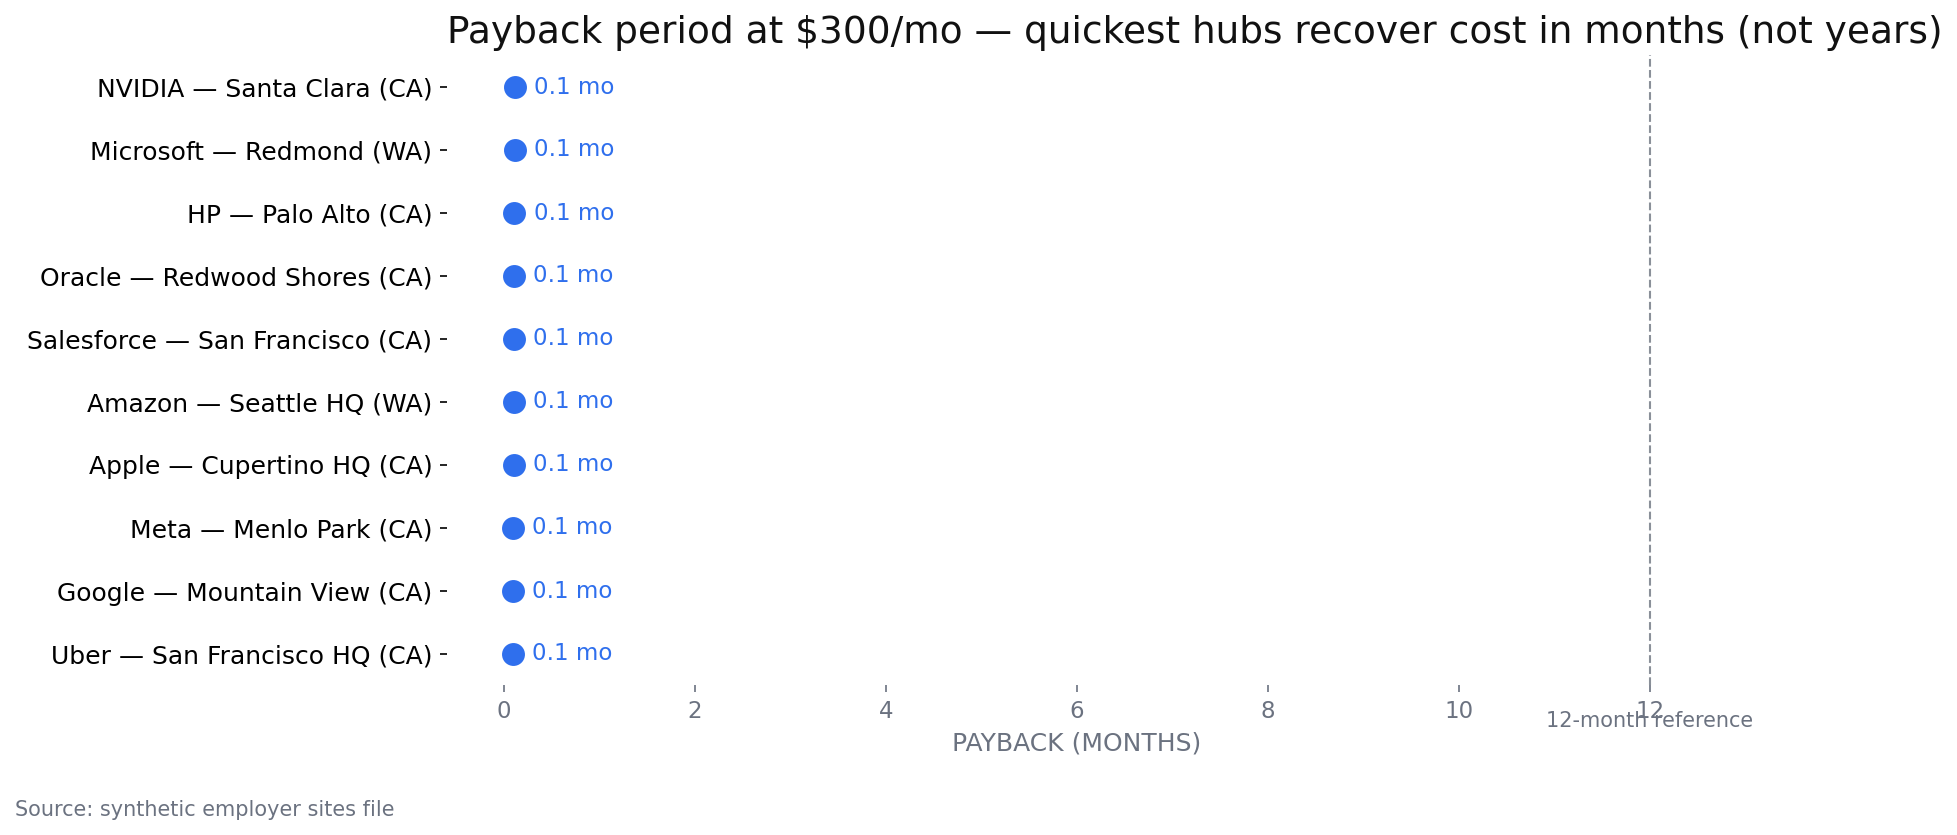

In [230]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---- Assumptions (tweak as needed) ----
STIPEND = 300                 # $/month per child
UPTAKE = 0.62                 # share of eligible employees who participate
RETENTION_LIFT = 0.12         # reduction in turnover among participants
REPLACEMENT_MULT = 1.15       # replacement cost as multiple of salary
ABS_DAYS_PER_YEAR = 7       # absenteeism days avoided per participant per year
WORK_DAYS = 240               # working days per year

ACCENT = "#2F6FED"
AXIS   = "#6B7280"
EDGE   = "#8A9099"

# ---- Load sites ----
sites = pd.read_csv("employer_sites_hr_synthetic_showcase.csv")

# Keep CA + WA and build a nice label
sub = (sites.loc[sites["State_Abbreviation"].isin(["CA","WA"])].copy())
sub["SiteLabel"] = (sub["Employer"].str.strip() + " — " +
                    sub["SiteName"].str.strip() + " (" + sub["State_Abbreviation"] + ")")

# Participants & children (simple, transparent mechanics)
sub["participants"] = sub["Headcount"] * sub["Percent_Parents_U6"] * UPTAKE
sub["children"]     = sub["participants"]  # 1 child per participating employee (assumption)

# Program cost per MONTH
sub["program_cost_month"] = STIPEND * sub["children"]

# Savings (annual → monthly)
# 1) Retention: prevented turnovers * replacement cost
turnovers_prevented = sub["Headcount"] * sub["Baseline_Turnover_Rate"] * RETENTION_LIFT * UPTAKE
retention_sav_annual = turnovers_prevented * (REPLACEMENT_MULT * sub["Avg_Salary"])

# 2) Absenteeism: avoided days * daily salary * participants
daily_salary = sub["Avg_Salary"] / WORK_DAYS
abs_sav_annual = daily_salary * ABS_DAYS_PER_YEAR * sub["participants"]

sub["savings_month"] = (retention_sav_annual + abs_sav_annual) / 12.0

# Payback (months to recover one month of program cost from monthly savings)
sub["payback_months"] = sub["program_cost_month"] / sub["savings_month"]
sub = sub.replace([np.inf, -np.inf], np.nan).dropna(subset=["payback_months"])

# Shorter is better — show the quickest 10 to keep it readable
top = sub.sort_values("payback_months").head(10).copy()
top = top[top["payback_months"] > 0]      # drop any zero/neg edge cases
top = top.assign(rank=np.arange(len(top)))

# ---- Plot (Cole-style) ----
fig, ax = plt.subplots(figsize=(12, 6))

y = np.arange(len(top))
x = top["payback_months"].values

# stems (subtle), dots (accent)
ax.hlines(y, 0, x, color="#D4D8DE", lw=2, zorder=1)
ax.plot(x, y, "o", color=ACCENT, ms=10, zorder=2)

# value labels (right of dot)
for xi, yi in zip(x, y):
    ax.text(xi + 0.2, yi, f"{xi:.1f} mo", va="center", ha="left", color=ACCENT, fontsize=11)

# y labels = site names
ax.set_yticks(y)
ax.set_yticklabels(top["SiteLabel"], fontsize=12)

# x axis: clean, uppercase, gray
ax.set_xlabel("PAYBACK (MONTHS)", color=AXIS, fontsize=12)
ax.tick_params(axis="x", colors=AXIS, labelsize=11)

# reference line at 12 months
ax.axvline(12, color=EDGE, lw=1, ls="--")
ax.text(12, -0.9, "12-month reference", color=AXIS, ha="center", va="top", fontsize=10)

# declutter
for s in ax.spines.values():
    s.set_visible(False)
ax.grid(False)
ax.set_ylim(-0.5, len(top)-0.5)
ax.margins(x=0.05)

# title + source
ax.set_title(f"Payback period at ${STIPEND}/mo — quickest hubs recover cost in months (not years)",
             loc="left", fontsize=18)
fig.subplots_adjust(bottom=0.18, left=0.25, right=0.95)
fig.text(0.01, 0.03, "Source: synthetic employer sites file",
         ha="left", va="bottom", color=AXIS, fontsize=10)

plt.show()
